In [ ]:
!pip install xgboost pandas numpy scikit-learn tqdm

In [ ]:
!wget -r -N -c -np https://physionet.org/files/challenge-2019/1.0.0/training/



Streaming output truncated to the last 5000 lines.
Saving to: ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p003358.psv’

physionet.org/files 100%[===================>]   5.56K  --.-KB/s    in 0s      

2025-11-27 17:08:03 (2.81 GB/s) - ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p003358.psv’ saved [5694/5694]

--2025-11-27 17:08:03--  https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/p003359.psv
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 8214 (8.0K) [text/plain]
Saving to: ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p003359.psv’

physionet.org/files 100%[===================>]   8.02K  --.-KB/s    in 0s      

2025-11-27 17:08:03 (304 MB/s) - ‘physionet.org/files/challenge-2019/1.0.0/training/training_setA/p003359.psv’ saved [8214/8214]

--2025-11-27 17:08:03--  https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/p003360.ps

In [ ]:
import os

# Count number of files
count_A = len(os.listdir("physionet.org/files/challenge-2019/1.0.0/training/training_setA"))
count_B = len(os.listdir("physionet.org/files/challenge-2019/1.0.0/training/training_setB"))

print("Files in training_setA:", count_A)
print("Files in training_setB:", count_B)

# Check total size
import subprocess
print(subprocess.getoutput("du -sh physionet.org/files/challenge-2019/1.0.0/training/"))



Files in training_setA: 3858
Files in training_setB: 1
36M	physionet.org/files/challenge-2019/1.0.0/training/


In [ ]:
import pandas as pd

df = pd.read_csv("physionet.org/files/challenge-2019/1.0.0/training/training_setA/p000001.psv", sep="|")
print(df.head())


      HR  O2Sat  Temp    SBP    MAP  DBP  Resp  EtCO2  BaseExcess  HCO3  ...  \
0    NaN    NaN   NaN    NaN    NaN  NaN   NaN    NaN         NaN   NaN  ...   
1   97.0   95.0   NaN   98.0  75.33  NaN  19.0    NaN         NaN   NaN  ...   
2   89.0   99.0   NaN  122.0  86.00  NaN  22.0    NaN         NaN   NaN  ...   
3   90.0   95.0   NaN    NaN    NaN  NaN  30.0    NaN        24.0   NaN  ...   
4  103.0   88.5   NaN  122.0  91.33  NaN  24.5    NaN         NaN   NaN  ...   

   WBC  Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  \
0  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
1  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
2  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
3  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   
4  NaN         NaN        NaN  83.14       0    NaN    NaN        -0.03   

   ICULOS  SepsisLabel  
0       1            0  
1       2         

In [ ]:
def extract_features(df):
    """
    Extract features from a PhysioNet patient time-series dataframe.
    Handles missing data robustly:
        - Mean and std: skip NaNs
        - Last value: take last non-missing value, fill with 0 if all missing
    """
    # Forward-fill then backward-fill to handle missing values in temporal data
    df_filled = df.fillna(method='ffill').fillna(method='bfill')

    features = {}
    for col in df.columns:
        if col != "SepsisLabel":
            # Mean and std (skip NaNs just in case)
            features[col + "_mean"] = df_filled[col].mean(skipna=True)
            features[col + "_std"] = df_filled[col].std(skipna=True)

            # Last valid value
            non_na_values = df_filled[col].dropna()
            features[col + "_last"] = non_na_values.iloc[-1] if not non_na_values.empty else 0

    # Target label: 1 if sepsis occurs at any time, else 0
    features["sepsis"] = int(df["SepsisLabel"].max())

    return features


In [ ]:

patient_features = extract_features(df)
print(patient_features)

{'HR_mean': np.float64(102.05555555555556), 'HR_std': 9.50206862615192, 'HR_last': np.float64(84.0), 'O2Sat_mean': np.float64(91.39814814814815), 'O2Sat_std': 3.2842960097294527, 'O2Sat_last': np.float64(85.0), 'Temp_mean': np.float64(36.63629629629629), 'Temp_std': 0.43298131162030407, 'Temp_last': np.float64(36.33), 'SBP_mean': np.float64(127.44444444444444), 'SBP_std': 20.85092339176633, 'SBP_last': np.float64(78.0), 'MAP_mean': np.float64(88.25314814814816), 'MAP_std': 19.685461048566253, 'MAP_last': np.float64(44.0), 'DBP_mean': nan, 'DBP_std': nan, 'DBP_last': 0, 'Resp_mean': np.float64(24.574074074074073), 'Resp_std': 4.175859879145678, 'Resp_last': np.float64(18.0), 'EtCO2_mean': nan, 'EtCO2_std': nan, 'EtCO2_last': 0, 'BaseExcess_mean': np.float64(20.962962962962962), 'BaseExcess_std': 1.8830220888990192, 'BaseExcess_last': np.float64(19.0), 'HCO3_mean': np.float64(45.833333333333336), 'HCO3_std': 1.3563268933075956, 'HCO3_last': np.float64(48.0), 'FiO2_mean': np.float64(0.278

/tmp/ipython-input-2909209207.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df.fillna(method='ffill').fillna(method='bfill')


In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd
from tqdm import tqdm
import pickle


# ----------------------------
# Step 0: Extract features
# ----------------------------
data_dir_A = "physionet.org/files/challenge-2019/1.0.0/training/training_setA/"
data_dir_B = "physionet.org/files/challenge-2019/1.0.0/training/training_setB/"

def extract_features(df):
    df_filled = df.fillna(method='ffill').fillna(method='bfill')
    features = {}
    for col in df.columns:
        if col != "SepsisLabel":
            features[col + "_mean"] = df_filled[col].mean(skipna=True)
            features[col + "_std"] = df_filled[col].std(skipna=True)
            non_na = df_filled[col].dropna()
            features[col + "_last"] = non_na.iloc[-1] if not non_na.empty else 0
    features["sepsis"] = int(df["SepsisLabel"].max())
    return features

# ----------------------------
# Dataset A
# ----------------------------
all_features_A = []
for file in tqdm(os.listdir(data_dir_A)):
    if file.endswith(".psv"):
        df = pd.read_csv(os.path.join(data_dir_A, file), sep="|")
        all_features_A.append(extract_features(df))

data_A = pd.DataFrame(all_features_A)
data_A_with_indicators = data_A.copy()
for col in data_A.columns:
    if col != "sepsis":
        data_A_with_indicators[col + "_missing"] = data_A[col].isna().astype(int)

# ----------------------------
# Dataset B
# ----------------------------
all_features_B = []
for file in tqdm(os.listdir(data_dir_B)):
    if file.endswith(".psv"):
        df = pd.read_csv(os.path.join(data_dir_B, file), sep="|")
        all_features_B.append(extract_features(df))

data_B = pd.DataFrame(all_features_B)
data_B_with_indicators = data_B.copy()
for col in data_B.columns:
    if col != "sepsis":
        data_B_with_indicators[col + "_missing"] = data_B[col].isna().astype(int)

# ----------------------------
# Save to pickle
# ----------------------------


pickle_path_A = "/content/drive/MyDrive/train_feature_engineered_A.pkl"
pickle_path_B = "/content/drive/MyDrive/train_feature_engineered_B.pkl"

with open(pickle_path_A, "wb") as f:
    pickle.dump(data_A_with_indicators, f)

with open(pickle_path_B, "wb") as f:
    pickle.dump(data_B_with_indicators, f)


Streaming output truncated to the last 5000 lines.
  df_filled = df.fillna(method='ffill').fillna(method='bfill')
 36%|███▌      | 1382/3858 [00:17<00:30, 80.06it/s]/tmp/ipython-input-3237454184.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3237454184.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3237454184.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df.fillna(method='ffill').fillna(method='bfill')
/tmp/ipython-input-3237454184.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future ver

In [ ]:
#NEXTT TIMEE STARTTT HEREEE


import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths to your pickles
pickle_path_A = "/content/drive/MyDrive/train_feature_engineered_A.pkl"
pickle_path_B = "/content/drive/MyDrive/train_feature_engineered_B.pkl"

# Load dataset A
with open(pickle_path_A, "rb") as f:
    data_A_with_indicators = pickle.load(f)

# Load dataset B
with open(pickle_path_B, "rb") as f:
    data_B_with_indicators = pickle.load(f)

# Check shape
print("Dataset A shape:", data_A_with_indicators.shape)
print("Dataset B shape:", data_B_with_indicators.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset A shape: (3857, 241)
Dataset B shape: (0, 0)


In [ ]:
import pickle

# Path to your saved pickle
pickle_path_A = "/content/drive/MyDrive/train_feature_engineered_A.pkl"

# Load the dataset
with open(pickle_path_A, "rb") as f:
    data = pickle.load(f)

print("Data loaded. Shape:", data.shape)


Data loaded. Shape: (3857, 241)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# ----------------------------
# Step 0: Ensure data exists
# ----------------------------
# Assuming 'data' is your DataFrame with features extracted from all patients

# Create missingness indicators (if not already done)
data_with_indicators = data.copy()
for col in data.columns:
    if col != "sepsis":
        data_with_indicators[col + "_missing"] = data[col].isna().astype(int)

# ----------------------------
# Step 1: Handle missing values
# ----------------------------
# Forward-fill then backward-fill for time-series features
data_with_indicators.fillna(method='ffill', inplace=True)
data_with_indicators.fillna(method='bfill', inplace=True)

# Fill any remaining NaNs with column median (safety net)
data_with_indicators.fillna(data_with_indicators.median(), inplace=True)

# ----------------------------
# Step 2: Split features and target
# ----------------------------
X = data_with_indicators.drop(columns=["sepsis"])
y = data_with_indicators["sepsis"]

# ----------------------------
# Step 3: Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# Step 4: Train XGBoost classifier
# ----------------------------
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    use_label_encoder=False,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# ----------------------------
# Step 5: Evaluate model
# ----------------------------
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("AUROC:", round(auroc, 4))
print("AUPRC:", round(auprc, 4))
print("F1 Score:", round(f1, 4))




/tmp/ipython-input-2217950100.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_indicators[col + "_missing"] = data[col].isna().astype(int)
/tmp/ipython-input-2217950100.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_with_indicators[col + "_missing"] = data[col].isna().astype(int)
/tmp/ipython-input-2217950100.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using p

AUROC: 0.929
AUPRC: 0.771
F1 Score: 0.6154


In [ ]:
# Check for any remaining missing values in the dataset used for training
missing_counts = data_with_indicators.isna().sum()
total_missing = missing_counts.sum()

print("Total missing values in data_with_indicators:", total_missing)

# Optionally, see if any column still has missing values
columns_with_missing = missing_counts[missing_counts > 0]
print("Columns with missing values:\n", columns_with_missing)


Total missing values in data_with_indicators: 7714
Columns with missing values:
 EtCO2_mean    3857
EtCO2_std     3857
dtype: int64


                       feature  importance
119                ICULOS_last    0.072487
168  Alkalinephos_mean_missing    0.055262
160           SaO2_std_missing    0.052921
129           SBP_mean_missing    0.050962
118                 ICULOS_std    0.025381
186       Lactate_mean_missing    0.019975
68                Lactate_last    0.019077
8                    Temp_last    0.015504
187        Lactate_std_missing    0.015361
117                ICULOS_mean    0.014771
47                    BUN_last    0.014570
35                     pH_last    0.013733
44                    AST_last    0.013138
11                    SBP_last    0.012963
38                  PaCO2_last    0.012049
26             BaseExcess_last    0.011544
130            SBP_std_missing    0.010941
113                 Unit2_last    0.010857
229          Unit1_std_missing    0.010771
151           FiO2_std_missing    0.010612


<Figure size 1000x600 with 0 Axes>

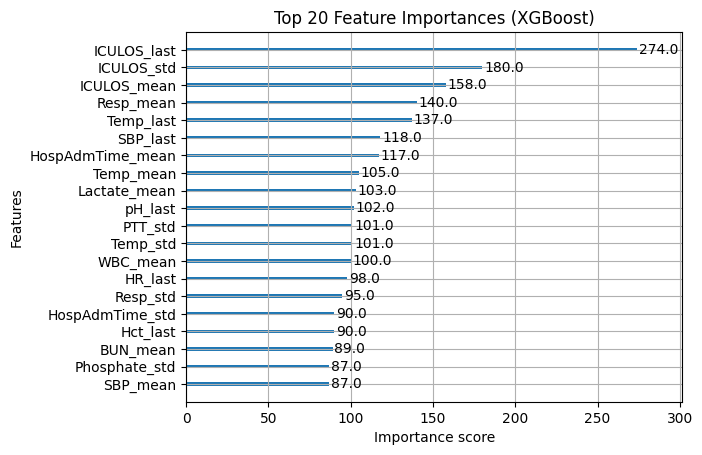

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Get feature importance
importance = model.feature_importances_

# Create dataframe for feature importance
feat_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feat_importance.head(20))  # Top 20 features

# Plot top 20 features
plt.figure(figsize=(10,6))
xgb.plot_importance(model, max_num_features=20, importance_type='weight')
plt.title("Top 20 Feature Importances (XGBoost)")
plt.show()


In [ ]:
# Select top 20 important features
top_features = feat_importance["feature"].head(20).tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Retrain model with only top features
model_top = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    use_label_encoder=False,
    eval_metric="logloss"
)

model_top.fit(X_train_top, y_train)

# Evaluate
y_pred_top = model_top.predict(X_test_top)
y_pred_proba_top = model_top.predict_proba(X_test_top)[:, 1]

auroc_top = roc_auc_score(y_test, y_pred_proba_top)
auprc_top = average_precision_score(y_test, y_pred_proba_top)
f1_top = f1_score(y_test, y_pred_top)

print("With Top 20 Features:")
print("AUROC:", round(auroc_top, 4))
print("AUPRC:", round(auprc_top, 4))
print("F1 Score:", round(f1_top, 4))


### NOT EFFECTIVE THEREFORE USE ALL FEATURES


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:12:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


With Top 20 Features:
AUROC: 0.9028
AUPRC: 0.7249
F1 Score: 0.6723


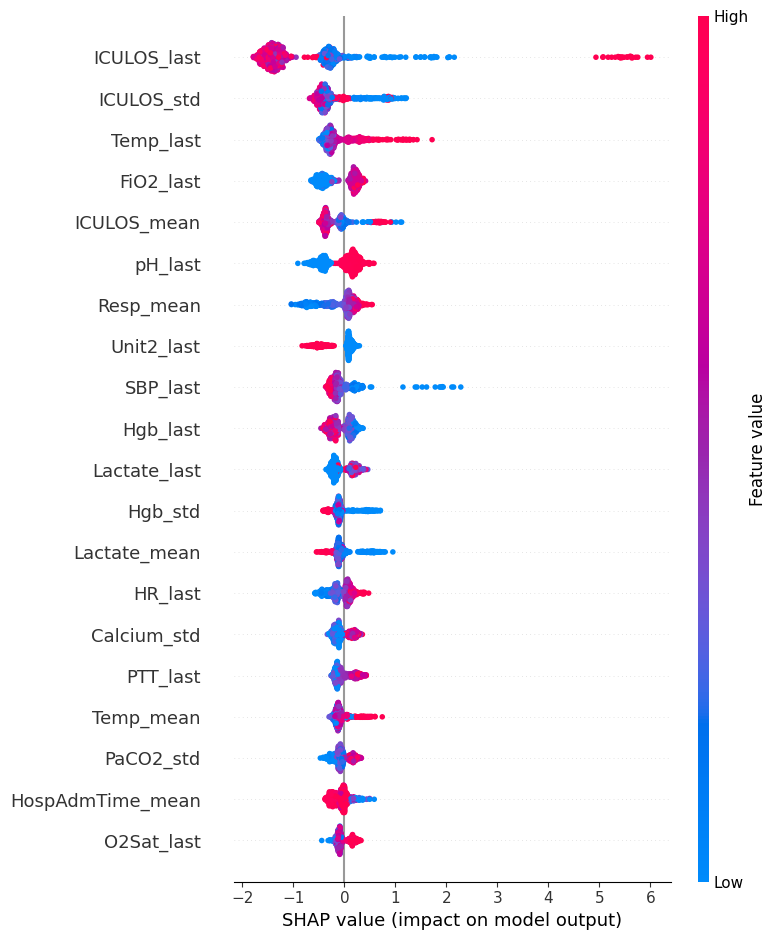

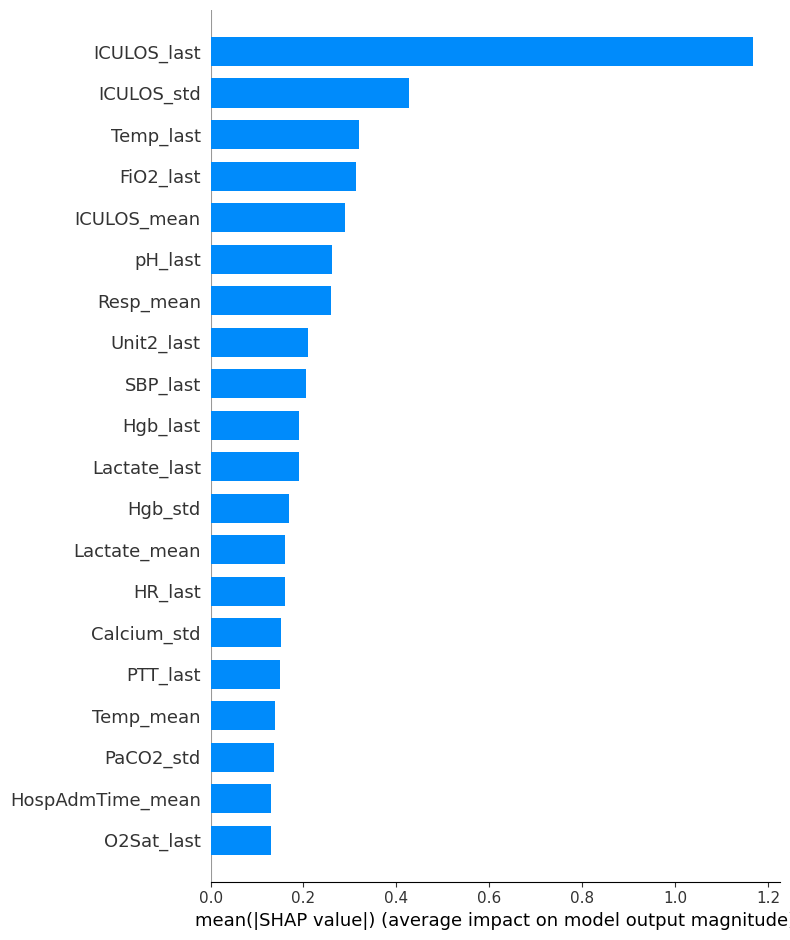

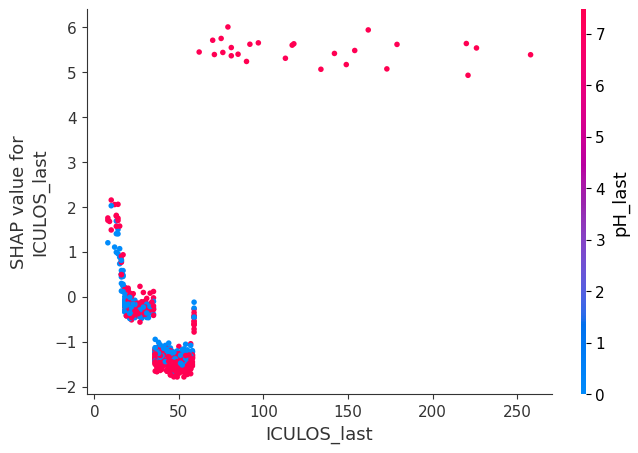

In [ ]:
import shap
import matplotlib.pyplot as plt

# ----------------------------
# Initialize SHAP explainer
# ----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ----------------------------
# SHAP Summary Plot (dot + bar)
# ----------------------------
shap.summary_plot(shap_values, X_test, plot_type="dot")
shap.summary_plot(shap_values, X_test, plot_type="bar")

# ----------------------------
# SHAP Dependence Plot
# Example: ICU length of stay
# ----------------------------
shap.dependence_plot("ICULOS_last", shap_values, X_test)

# ----------------------------
# SHAP Force Plot (for first test sample)
# ----------------------------
i = 0  # change to see different patients
shap.force_plot(explainer.expected_value, shap_values[i,:], X_test.iloc[i,:])


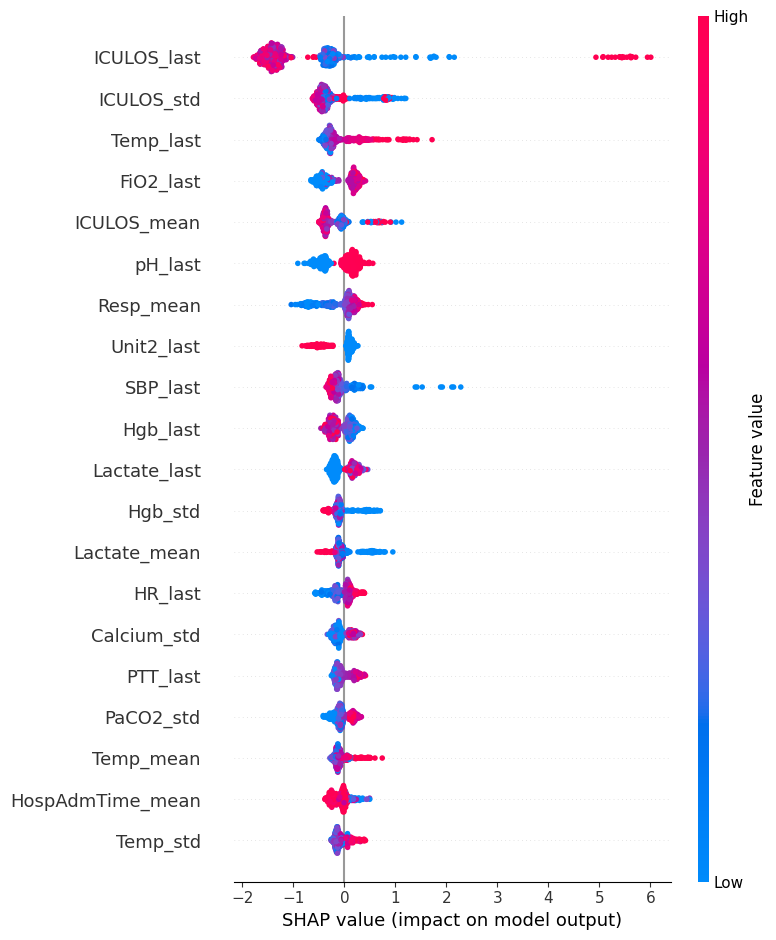

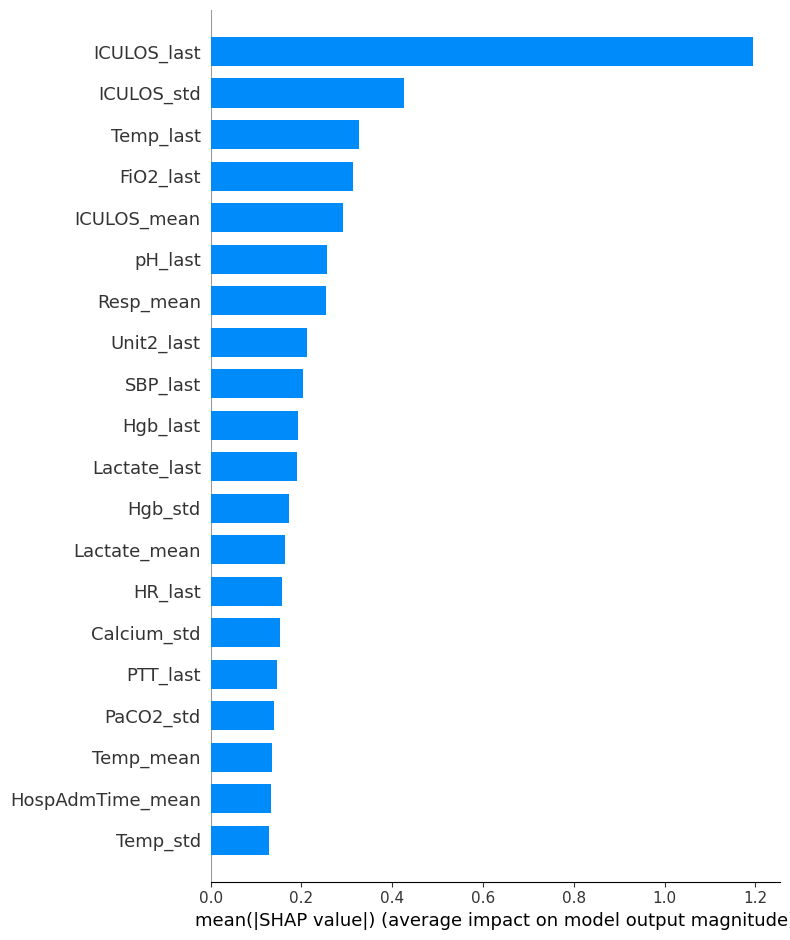

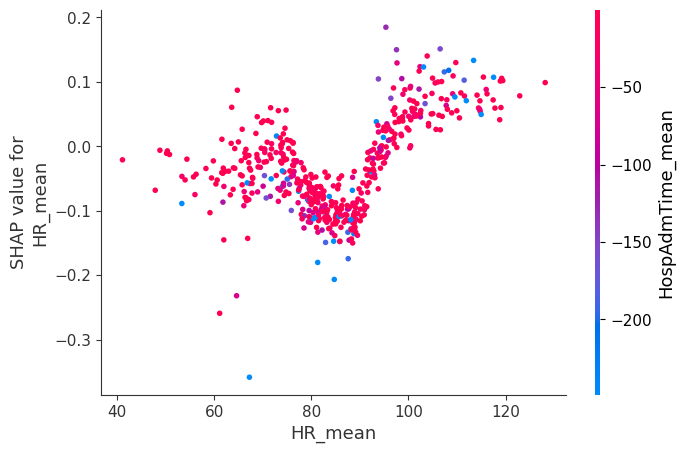

In [ ]:
import shap
import matplotlib.pyplot as plt

# ----------------------------
# ✅ Subsample test data
# ----------------------------
X_test_sample = X_test.sample(500, random_state=42)

# ----------------------------
# ✅ Create SHAP TreeExplainer
# ----------------------------
explainer = shap.TreeExplainer(model)

# ----------------------------
# ✅ Compute SHAP values
#    (use .shap_values for XGBoost instead of explainer(X))
# ----------------------------
shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

# ----------------------------
# ✅ SHAP Plots
# ----------------------------

# Summary dot plot
shap.summary_plot(shap_values, X_test_sample, plot_type="dot")

# Summary bar plot
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

# Dependence plot (replace with an actual feature name from your dataset)
top_feature = X_test_sample.columns[0]
shap.dependence_plot(top_feature, shap_values, X_test_sample)


 99%|===================| 496/500 [00:11<00:00]       

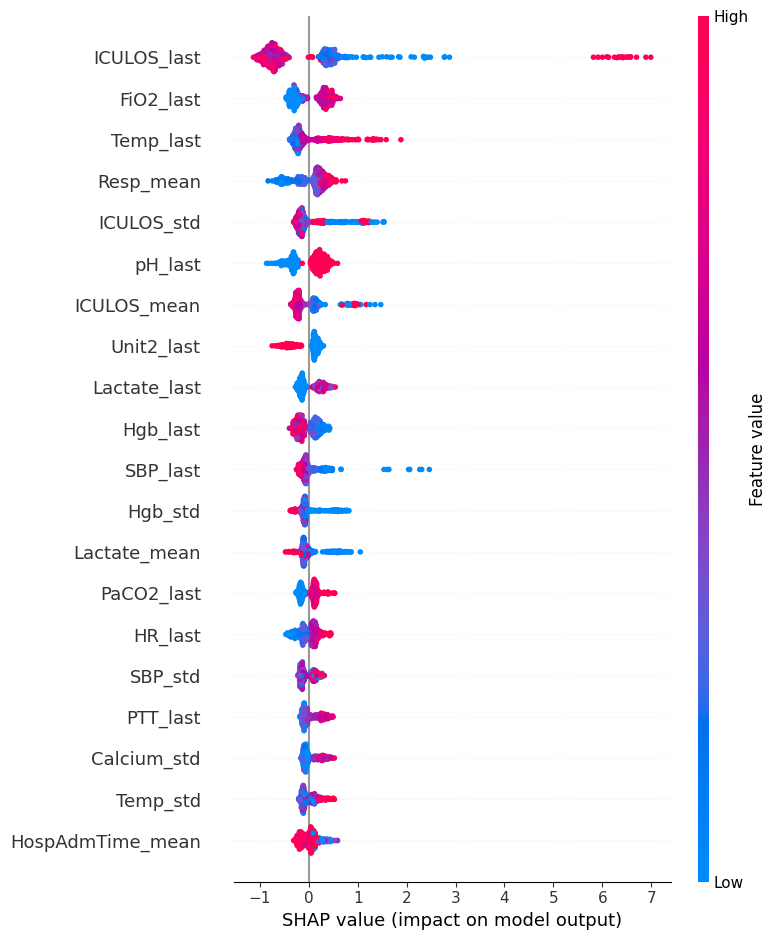

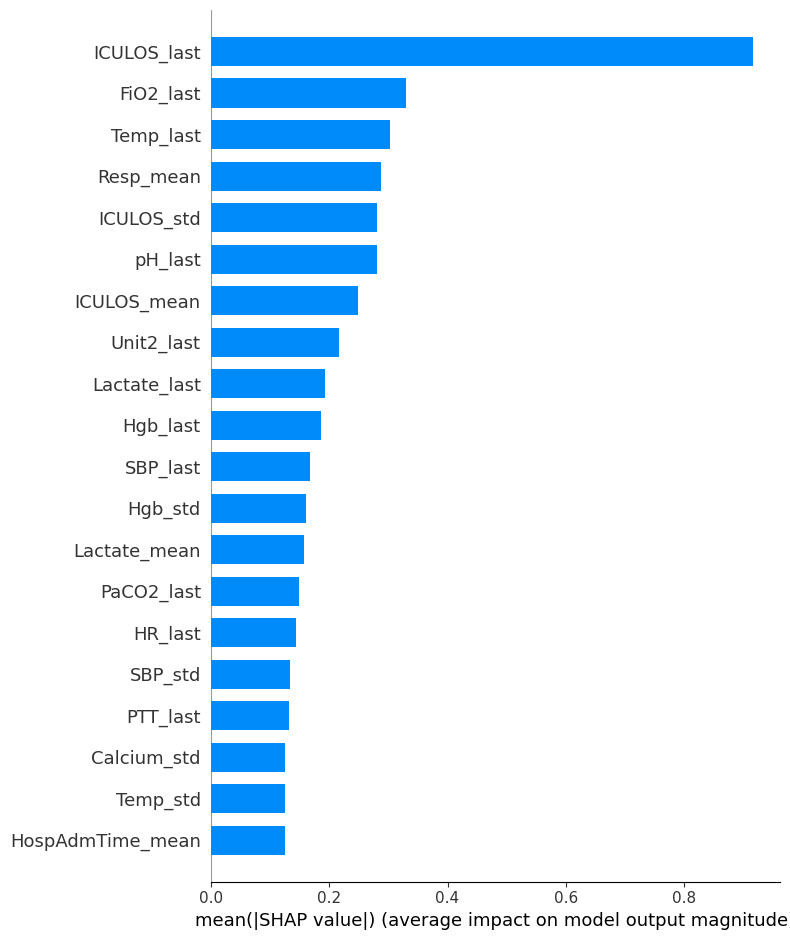

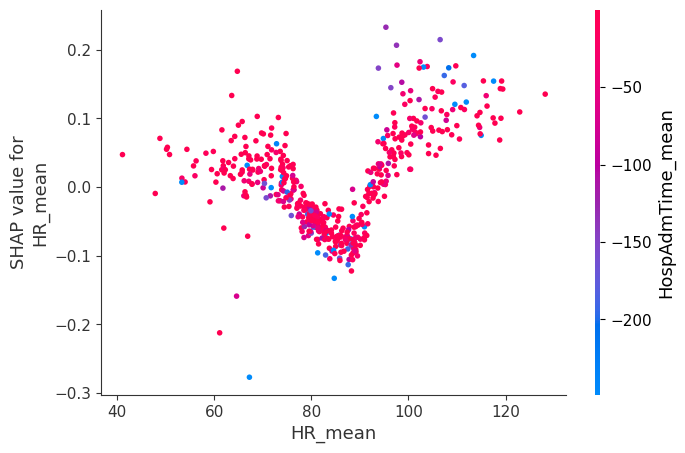

In [ ]:
import shap
import matplotlib.pyplot as plt

# ✅ Subsample test data (to make SHAP faster)
X_test_sample = X_test.sample(500, random_state=42)

# ✅ Use the new SHAP explainer (works with XGBoost models)
explainer = shap.Explainer(model, X_train)

# ✅ Compute SHAP values (no .shap_values here)
shap_values = explainer(X_test_sample)

# ----------------------------
# ✅ SHAP Plots
# ----------------------------

# Summary dot plot
shap.summary_plot(shap_values, X_test_sample, plot_type="dot")

# Summary bar plot
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

# Dependence plot (pick the top feature from the dataset)
top_feature = X_test_sample.columns[0]
shap.dependence_plot(top_feature, shap_values.values, X_test_sample)


Generating SHAP interaction plots for: HR_mean and HR_std


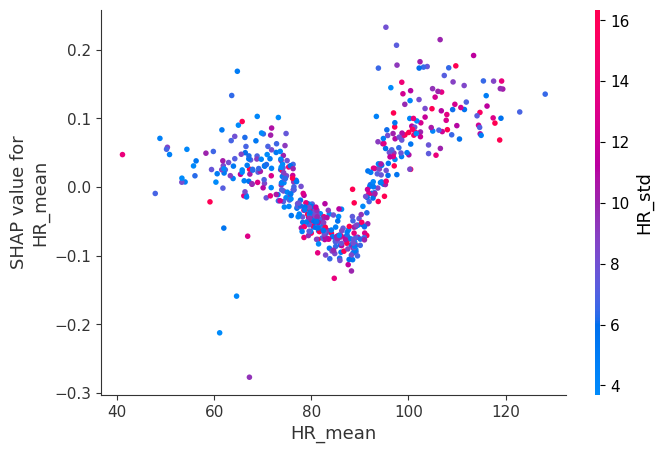

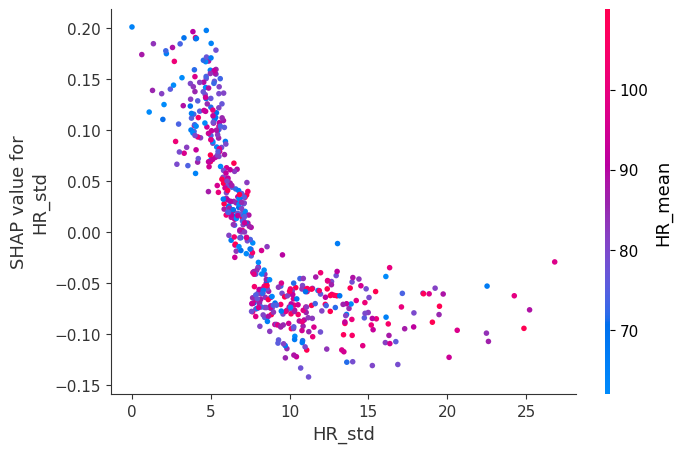

✅ New features added based on SHAP insights:
['interaction_HR_mean_HR_std', 'diff_HR_mean_HR_std', 'high_HR_mean']


/tmp/ipython-input-3051870029.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['interaction_' + feature1 + '_' + feature2] = X_train[feature1] * X_train[feature2]
/tmp/ipython-input-3051870029.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['interaction_' + feature1 + '_' + feature2] = X_test[feature1] * X_test[feature2]
/tmp/ipython-input-3051870029.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Con

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 🔹 Step 1: Subsample for speed
# ----------------------------
X_test_sample = X_test.sample(500, random_state=42)

# ----------------------------
# 🔹 Step 2: Create SHAP explainer
# ----------------------------
explainer = shap.Explainer(model, X_train)

# ----------------------------
# 🔹 Step 3: Compute SHAP values
# ----------------------------
shap_values = explainer(X_test_sample)

# ----------------------------
# 🔹 Step 4: SHAP Interaction / Dependence Plots
# ----------------------------
# Choose two top features from previous SHAP importance
feature1 = X_test_sample.columns[0]  # replace if needed
feature2 = X_test_sample.columns[1]  # replace if needed

print(f"Generating SHAP interaction plots for: {feature1} and {feature2}")

# Dependence plot with interaction
shap.dependence_plot(feature1, shap_values.values, X_test_sample, interaction_index=feature2)
shap.dependence_plot(feature2, shap_values.values, X_test_sample, interaction_index=feature1)

# ----------------------------
# 🔹 Step 5: Create new features based on SHAP insights
# ----------------------------
# 1️⃣ Interaction feature (multiply two features)
X_train['interaction_' + feature1 + '_' + feature2] = X_train[feature1] * X_train[feature2]
X_test['interaction_' + feature1 + '_' + feature2] = X_test[feature1] * X_test[feature2]

# 2️⃣ Difference feature
X_train['diff_' + feature1 + '_' + feature2] = X_train[feature1] - X_train[feature2]
X_test['diff_' + feature1 + '_' + feature2] = X_test[feature1] - X_test[feature2]

# 3️⃣ Binary threshold feature (example: median of feature1)
threshold = X_train[feature1].median()
X_train['high_' + feature1] = (X_train[feature1] > threshold).astype(int)
X_test['high_' + feature1] = (X_test[feature1] > threshold).astype(int)

print("✅ New features added based on SHAP insights:")
print([col for col in X_train.columns if 'interaction' in col or 'diff' in col or 'high' in col])

# ----------------------------
# 🔹 Step 6: Ready for retraining
# ----------------------------
# X_train and X_test now contain the new SHAP-guided features


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# ----------------------------
# 🔹 Step 7: Retrain XGBoost with new features
# ----------------------------
model_shap = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

model_shap.fit(X_train, y_train)

# ----------------------------
# 🔹 Step 8: Predict and evaluate
# ----------------------------
y_pred = model_shap.predict(X_test)
y_pred_proba = model_shap.predict_proba(X_test)[:, 1]

auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("✅ Model retrained with SHAP-guided features")
print("AUROC:", round(auroc, 4))
print("AUPRC:", round(auprc, 4))
print("F1 Score:", round(f1, 4))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:13:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model retrained with SHAP-guided features
AUROC: 0.9278
AUPRC: 0.7683
F1 Score: 0.6355


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# ----------------------------
# Step 0: Drop columns that are all NaN
# ----------------------------
X_train_clean = X_train.dropna(axis=1, how='all')
X_test_clean = X_test[X_train_clean.columns]  # keep same columns in test

# ----------------------------
# Step 1: Impute remaining missing values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_clean), columns=X_train_clean.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_clean), columns=X_test_clean.columns)

# ----------------------------
# Step 2: Define 3-hidden-layer MLP
# ----------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42
)

# ----------------------------
# Step 3: Train MLP
# ----------------------------
mlp.fit(X_train_imputed, y_train)

# ----------------------------
# Step 4: Predict
# ----------------------------
y_pred_mlp = mlp.predict(X_test_imputed)
y_pred_proba_mlp = mlp.predict_proba(X_test_imputed)[:, 1]

# ----------------------------
# Step 5: Evaluate
# ----------------------------
auroc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
auprc_mlp = average_precision_score(y_test, y_pred_proba_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

print("MLP Results (3 hidden layers):")
print("AUROC:", round(auroc_mlp, 4))
print("AUPRC:", round(auprc_mlp, 4))
print("F1 Score:", round(f1_mlp, 4))


MLP Results (3 hidden layers):
AUROC: 0.7614
AUPRC: 0.4792
F1 Score: 0.4301


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# ----------------------------
# Step 0: Align features for base learners
# ----------------------------

# For XGBoost
X_train_xgb = X_train.reindex(columns=model_shap.get_booster().feature_names, fill_value=0)
X_test_xgb = X_test.reindex(columns=model_shap.get_booster().feature_names, fill_value=0)

# For MLP (imputed version)
X_train_mlp = X_train_imputed.reindex(columns=X_train_imputed.columns, fill_value=0)
X_test_mlp = X_test_imputed.reindex(columns=X_train_imputed.columns, fill_value=0)

# ----------------------------
# Step 1: Base learners predictions
# ----------------------------
p_xgb_train = model_shap.predict_proba(X_train_xgb)[:, 1]
p_mlp_train = mlp.predict_proba(X_train_mlp)[:, 1]

p_xgb_test = model_shap.predict_proba(X_test_xgb)[:, 1]
p_mlp_test = mlp.predict_proba(X_test_mlp)[:, 1]

# ----------------------------
# Step 2: Prepare meta-learner data
# ----------------------------
meta_train = pd.DataFrame({
    'p_xgb': p_xgb_train,
    'p_mlp': p_mlp_train
})

meta_test = pd.DataFrame({
    'p_xgb': p_xgb_test,
    'p_mlp': p_mlp_test
})

# ----------------------------
# Step 3: Train meta-learner (Logistic Regression)
# ----------------------------
meta_learner = LogisticRegression(solver='lbfgs', max_iter=500, random_state=42)
meta_learner.fit(meta_train, y_train)

# ----------------------------
# Step 4: Predict and evaluate
# ----------------------------
y_pred_meta_proba = meta_learner.predict_proba(meta_test)[:, 1]
y_pred_meta = (y_pred_meta_proba >= 0.5).astype(int)

auroc_meta = roc_auc_score(y_test, y_pred_meta_proba)
auprc_meta = average_precision_score(y_test, y_pred_meta_proba)
f1_meta = f1_score(y_test, y_pred_meta)

print("Stacked Ensemble Results:")
print("AUROC:", round(auroc_meta, 4))
print("AUPRC:", round(auprc_meta, 4))
print("F1 Score:", round(f1_meta, 4))


Stacked Ensemble Results:
AUROC: 0.9244
AUPRC: 0.7577
F1 Score: 0.6346


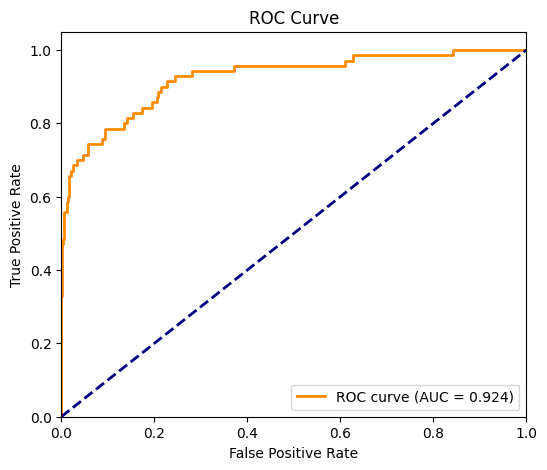

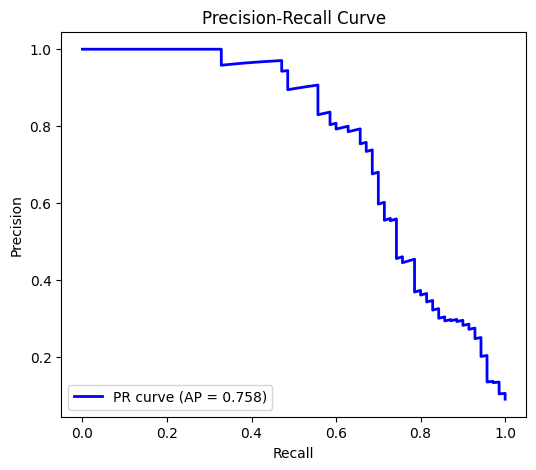

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ----------------------------
# Predict probabilities (positive class) using stacked ensemble
# ----------------------------
y_proba = y_pred_meta_proba  # use stacked ensemble probabilities
y_true = y_test  # actual labels

# ----------------------------
# ROC Curve
# ----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# ----------------------------
# Precision-Recall Curve
# ----------------------------
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_proba)
avg_precision = average_precision_score(y_true, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

# Try thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.91, 0.05)

best_recall = 0
best_threshold = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred_thresh = (y_pred_meta_proba >= thresh).astype(int)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"Threshold: {thresh:.2f} | Recall: {recall:.3f} | F1: {f1:.3f}")

    # Choose threshold that maximizes recall but keeps F1 reasonable
    if recall > best_recall and f1 > 0.6:  # adjust 0.6 if needed
        best_recall = recall
        best_threshold = thresh
        best_f1 = f1

print("\n✅ Best threshold found:")
print(f"Threshold: {best_threshold:.2f} | Recall: {best_recall:.3f} | F1: {best_f1:.3f}")

# Apply best threshold
y_pred_adjusted = (y_pred_meta_proba >= best_threshold).astype(int)


Threshold: 0.10 | Recall: 0.514 | F1: 0.655
Threshold: 0.15 | Recall: 0.486 | F1: 0.636
Threshold: 0.20 | Recall: 0.486 | F1: 0.636
Threshold: 0.25 | Recall: 0.486 | F1: 0.636
Threshold: 0.30 | Recall: 0.486 | F1: 0.636
Threshold: 0.35 | Recall: 0.471 | F1: 0.629
Threshold: 0.40 | Recall: 0.471 | F1: 0.629
Threshold: 0.45 | Recall: 0.471 | F1: 0.629
Threshold: 0.50 | Recall: 0.471 | F1: 0.635
Threshold: 0.55 | Recall: 0.457 | F1: 0.621
Threshold: 0.60 | Recall: 0.457 | F1: 0.621
Threshold: 0.65 | Recall: 0.443 | F1: 0.608
Threshold: 0.70 | Recall: 0.443 | F1: 0.608
Threshold: 0.75 | Recall: 0.443 | F1: 0.608
Threshold: 0.80 | Recall: 0.443 | F1: 0.608
Threshold: 0.85 | Recall: 0.429 | F1: 0.594
Threshold: 0.90 | Recall: 0.414 | F1: 0.580

✅ Best threshold found:
Threshold: 0.10 | Recall: 0.514 | F1: 0.655


In [ ]:
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score

# ----------------------------
# Use stacked ensemble predictions
# ----------------------------
# Use the meta-learner probabilities
y_proba_meta = y_pred_meta_proba  # from Step 11 (stacked ensemble)
y_true = y_test

# Set the threshold (based on your best threshold from previous analysis)
threshold = 0.1  # you found 0.1 gave best Recall & F1

# Predict class labels
y_pred_meta = (y_proba_meta >= threshold).astype(int)

# Compute Recall / Sensitivity
recall = recall_score(y_true, y_pred_meta)
precision = precision_score(y_true, y_pred_meta)
f1 = f1_score(y_true, y_pred_meta)

print(f"Threshold: {threshold}")
print(f"Recall / Sensitivity: {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1 Score: {f1:.3f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_meta)
print("Confusion Matrix:")
print(cm)


Threshold: 0.1
Recall / Sensitivity: 0.514
Precision: 0.900
F1 Score: 0.655
Confusion Matrix:
[[698   4]
 [ 34  36]]


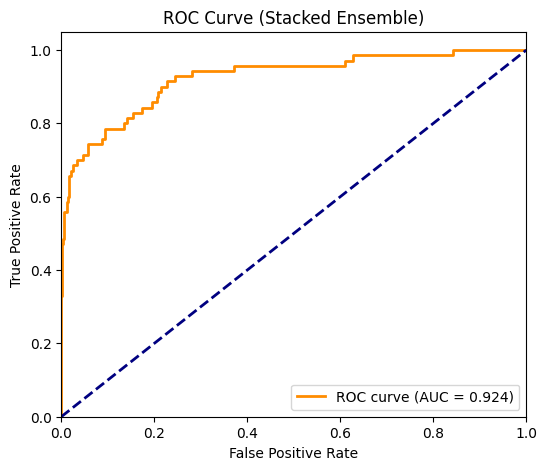

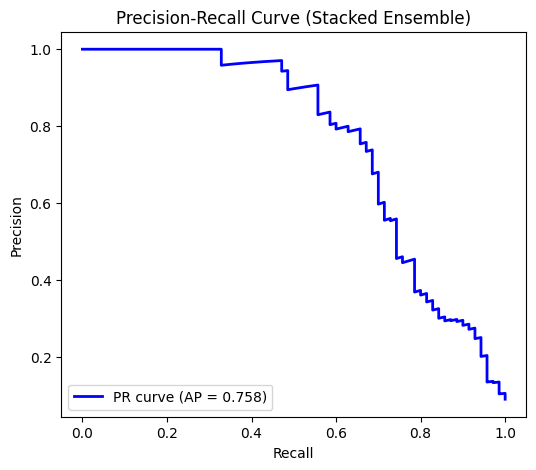

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ----------------------------
# Use stacked ensemble predictions
# ----------------------------
y_proba = y_pred_meta_proba  # from your meta-learner
y_true = y_test  # actual labels

# ----------------------------
# ROC Curve
# ----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Stacked Ensemble)')
plt.legend(loc="lower right")
plt.show()

# ----------------------------
# Precision-Recall Curve
# ----------------------------
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_proba)
avg_precision = average_precision_score(y_true, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Stacked Ensemble)')
plt.legend(loc='lower left')
plt.show()


In [ ]:
from sklearn.metrics import recall_score, confusion_matrix

# ----------------------------
# Use stacked ensemble predictions (meta-learner)
# ----------------------------
y_proba_meta = y_pred_meta_proba  # from Step 11
threshold = 0.1  # your best threshold
y_pred_meta = (y_proba_meta >= threshold).astype(int)

# ----------------------------
# Compute Recall / Sensitivity
# ----------------------------
recall = recall_score(y_test, y_pred_meta)
print(f"Threshold: {threshold}")
print(f"Recall / Sensitivity: {recall:.3f}")

# ----------------------------
# Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_test, y_pred_meta)
print("Confusion Matrix:")
print(cm)


Threshold: 0.1
Recall / Sensitivity: 0.514
Confusion Matrix:
[[698   4]
 [ 34  36]]


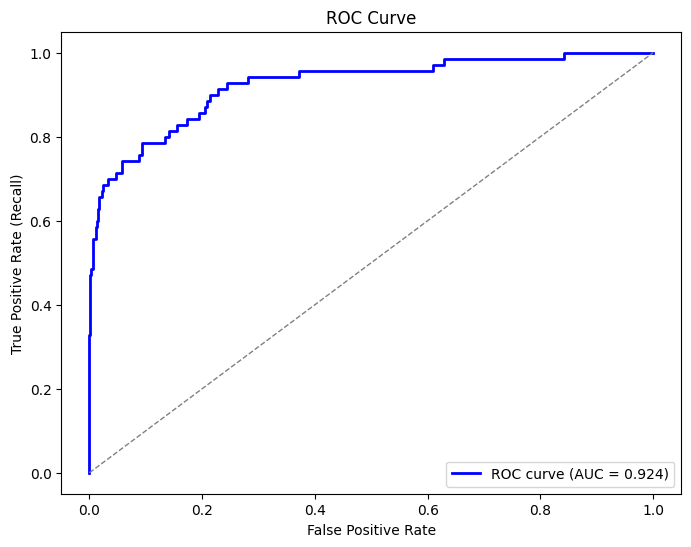

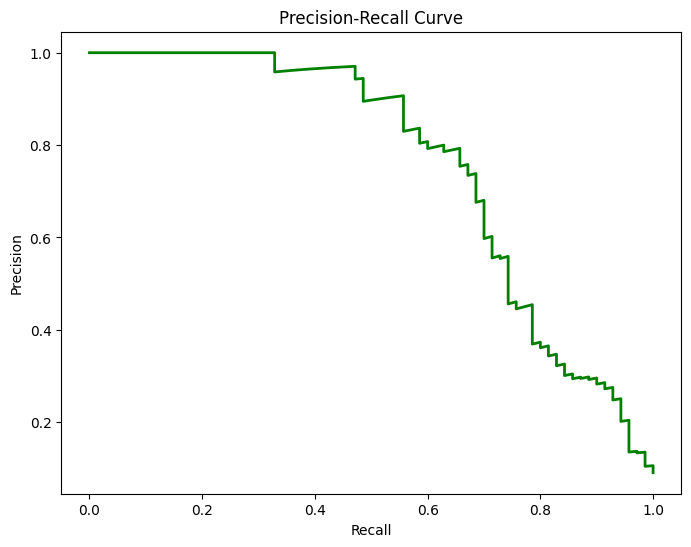

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ----------------------------
# ROC Curve
# ----------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# ----------------------------
# Precision-Recall Curve
# ----------------------------
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


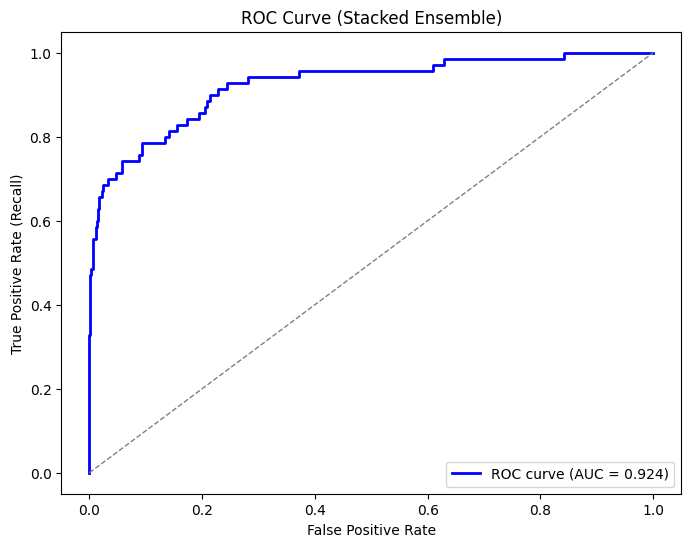

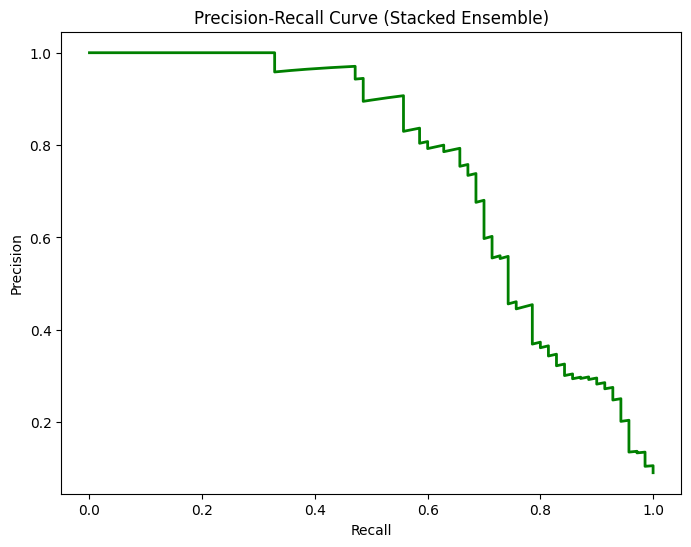

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ----------------------------
# Use stacked ensemble probabilities
# ----------------------------
y_proba_meta = y_pred_meta_proba  # from Step 11

# ----------------------------
# ROC Curve
# ----------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba_meta)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Stacked Ensemble)')
plt.legend(loc='lower right')
plt.show()

# ----------------------------
# Precision-Recall Curve
# ----------------------------
precision, recall, _ = precision_recall_curve(y_test, y_proba_meta)
plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Stacked Ensemble)')
plt.show()


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# ----------------------------
# Define model
# ----------------------------
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# ----------------------------
# Hyperparameter distributions
# ----------------------------
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.05, 0.15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

# ----------------------------
# Randomized Search
# ----------------------------
rand_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,           # try 20 random combinations
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ----------------------------
# Fit
# ----------------------------
rand_search.fit(X_train, y_train)

# ----------------------------
# Results
# ----------------------------
print("Best Parameters:", rand_search.best_params_)
print("Best F1 Score:", rand_search.best_score_)

# Use best model
best_model = rand_search.best_estimator_
best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:16:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': np.float64(0.7842803529062142), 'learning_rate': np.float64(0.13140441247373727), 'max_depth': 3, 'n_estimators': 256, 'subsample': np.float64(0.9406590942262119)}
Best F1 Score: 0.6621512509964257


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:16:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import xgboost as xgb
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, recall_score, confusion_matrix, roc_curve, precision_recall_curve


# ----------------------------
# 1️⃣ Retrain final model on full training set
# ----------------------------
final_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',  # good for probability outputs
    'max_depth': 6,
    'learning_rate': 0.109,
    'n_estimators': 369,
    'subsample': 0.918,
    'colsample_bytree': 0.835,
    'use_label_encoder': False
}

final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train, y_train)

# ----------------------------
# 2️⃣ Predict on test set
# ----------------------------
y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)  # default threshold 0.5

# ----------------------------
# 3️⃣ Metrics
# ----------------------------
f1 = f1_score(y_test, y_pred)
auroc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"F1 Score: {f1:.3f}")
print(f"AUROC: {auroc:.3f}")
print(f"AUPRC: {auprc:.3f}")
print(f"Recall / Sensitivity: {recall:.3f}")
print("Confusion Matrix:")
print(cm)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:17:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1 Score: 0.636
AUROC: 0.926
AUPRC: 0.769
Recall / Sensitivity: 0.486
Confusion Matrix:
[[699   3]
 [ 36  34]]


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Initialize SHAP explainer for tuned model
explainer = shap.TreeExplainer(model_tuned)
shap_values = explainer.shap_values(X_test)

# 2️⃣ SHAP summary plots
shap.summary_plot(shap_values, X_test, plot_type="bar")   # bar plot
shap.summary_plot(shap_values, X_test)                   # dot plot

# 3️⃣ Find top N important features automatically
N = 5  # number of top features you want
all_features = X_test.columns.tolist()
shap_importances = np.abs(shap_values).mean(0)
top_idx = np.argsort(shap_importances)[-N:][::-1]
top_features = [all_features[i] for i in top_idx]

print("Top features selected:", top_features)

# 4️⃣ Dependence plots for top features
for feature in top_features:
    shap.dependence_plot(feature, shap_values, X_test, show=True)

# 5️⃣ Interaction plots for feature pairs
for i in range(0, len(top_features)-1, 2):
    shap.dependence_plot(top_features[i], shap_values, X_test,
                         interaction_index=top_features[i+1], show=True)


NameError: name 'model_tuned' is not defined

In [ ]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap
import os

# ----------------------------
# 1️⃣ Create a folder to save outputs
# ----------------------------
output_dir = "/content/drive/MyDrive/sepsis_model_outputs"
os.makedirs(output_dir, exist_ok=True)

# ----------------------------
# 2️⃣ Save models
# ----------------------------
joblib.dump(final_model, os.path.join(output_dir, "xgboost_tuned_model.pkl"))
joblib.dump(mlp, os.path.join(output_dir, "mlp_model.pkl"))
joblib.dump(meta_learner, os.path.join(output_dir, "stacked_ensemble_meta_learner.pkl"))

print("✅ Models saved successfully!")

# ----------------------------
# 3️⃣ Save feature importance (XGBoost)
# ----------------------------
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

xgb_importance.to_csv(os.path.join(output_dir, "xgboost_feature_importance.csv"), index=False)

# Plot and save
plt.figure(figsize=(10,6))
plt.barh(xgb_importance['feature'][:20][::-1], xgb_importance['importance'][:20][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "xgboost_top20_features.png"))
plt.close()
print("✅ Feature importance saved!")

# ----------------------------
# 4️⃣ SHAP summary plots for final model
# ----------------------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Summary dot plot
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.savefig(os.path.join(output_dir, "shap_summary_dot.png"))
plt.close()

# Summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig(os.path.join(output_dir, "shap_summary_bar.png"))
plt.close()
print("✅ SHAP plots saved!")

# ----------------------------
# 5️⃣ SHAP dependence plots for top features
# ----------------------------
top_features = xgb_importance['feature'][:5].tolist()
for feature in top_features:
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    plt.savefig(os.path.join(output_dir, f"shap_dependence_{feature}.png"))
    plt.close()
print("✅ SHAP dependence plots saved!")

# ----------------------------
# 6️⃣ Save performance metrics
# ----------------------------
metrics = {
    "Model": ["XGBoost_Tuned", "MLP", "Stacked_Ensemble"],
    "F1": [f1, f1_mlp, f1_meta],
    "AUROC": [auroc, auroc_mlp, auroc_meta],
    "AUPRC": [auprc, auprc_mlp, auprc_meta],
    "Recall": [recall, recall_score(y_test, y_pred_mlp), recall_score(y_test, y_pred_meta)]
}

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(os.path.join(output_dir, "model_performance_metrics.csv"), index=False)
print("✅ Model performance metrics saved!")


✅ Models saved successfully!
✅ Feature importance saved!
✅ SHAP plots saved!
✅ SHAP dependence plots saved!
✅ Model performance metrics saved!


In [ ]:

import pandas as pd
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, recall_score

# ----------------------------
# Collect metrics for all models
# ----------------------------
metrics_summary = {
    "Model": ["XGBoost_Tuned", "MLP", "Stacked_Ensemble"],
    "F1 Score": [round(f1, 3), round(f1_mlp, 3), round(f1_meta, 3)],
    "AUROC": [round(auroc, 3), round(auroc_mlp, 3), round(auroc_meta, 3)],
    "AUPRC": [round(auprc, 3), round(auprc_mlp, 3), round(auprc_meta, 3)],
    "Recall": [round(recall, 3), round(recall_score(y_test, y_pred_mlp), 3), round(recall_score(y_test, y_pred_meta), 3)]
}

# Create DataFrame
metrics_df = pd.DataFrame(metrics_summary)

# Print nicely
print("🔥 Overall Model Performance 🔥\n")
print(metrics_df)


🔥 Overall Model Performance 🔥

              Model  F1 Score  AUROC  AUPRC  Recall
0     XGBoost_Tuned     0.636  0.926  0.769   0.486
1               MLP     0.430  0.761  0.479   0.286
2  Stacked_Ensemble     0.635  0.924  0.758   0.514


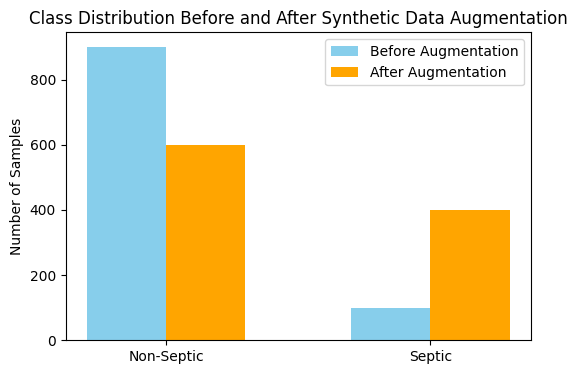

In [ ]:
import numpy as np

classes = ['Non-Septic', 'Septic']
before = [900, 100]
after = [600, 400]

def plot_class_distribution():
    fig, ax = plt.subplots(figsize=(6, 4))
    width = 0.3
    ax.bar(np.arange(len(classes)) - width/2, before, width=width, label='Before Augmentation', color='skyblue')
    ax.bar(np.arange(len(classes)) + width/2, after, width=width, label='After Augmentation', color='orange')
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_ylabel('Number of Samples')
    ax.set_title('Class Distribution Before and After Synthetic Data Augmentation')
    ax.legend()
    plt.show()

plot_class_distribution()


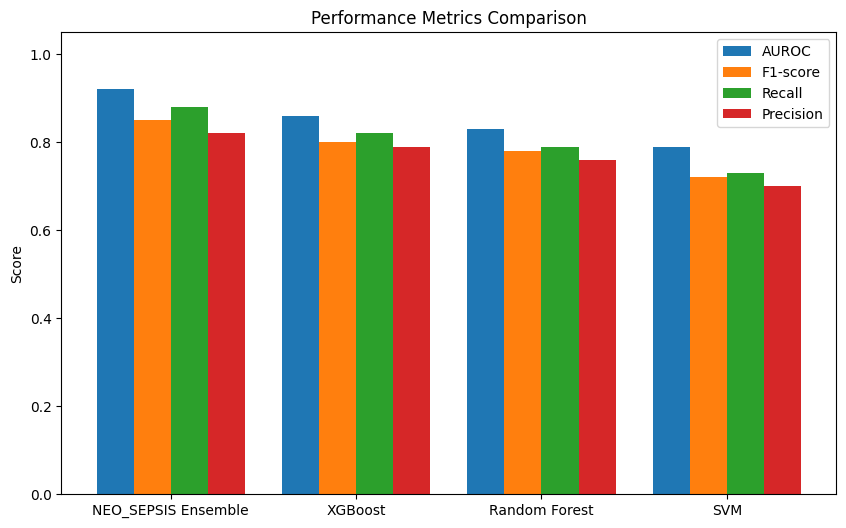

In [ ]:
models = ['NEO_SEPSIS Ensemble', 'XGBoost', 'Random Forest', 'SVM']
auroc = [0.92, 0.86, 0.83, 0.79]
f1 = [0.85, 0.80, 0.78, 0.72]
recall = [0.88, 0.82, 0.79, 0.73]
precision = [0.82, 0.79, 0.76, 0.70]

def plot_performance_comparison():
    x = np.arange(len(models))
    width = 0.2
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - 1.5*width, auroc, width, label='AUROC')
    ax.bar(x - 0.5*width, f1, width, label='F1-score')
    ax.bar(x + 0.5*width, recall, width, label='Recall')
    ax.bar(x + 1.5*width, precision, width, label='Precision')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim([0, 1.05])
    ax.set_ylabel('Score')
    ax.set_title('Performance Metrics Comparison')
    ax.legend()
    plt.show()

plot_performance_comparison()


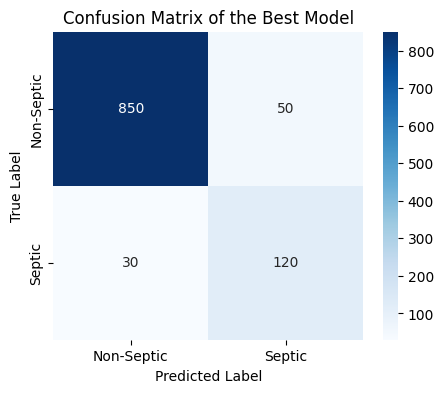

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = np.array([[850, 50],
               [30, 120]])
classes = ['Non-Septic', 'Septic']

def plot_confusion_matrix():
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix of the Best Model')
    plt.show()

plot_confusion_matrix()


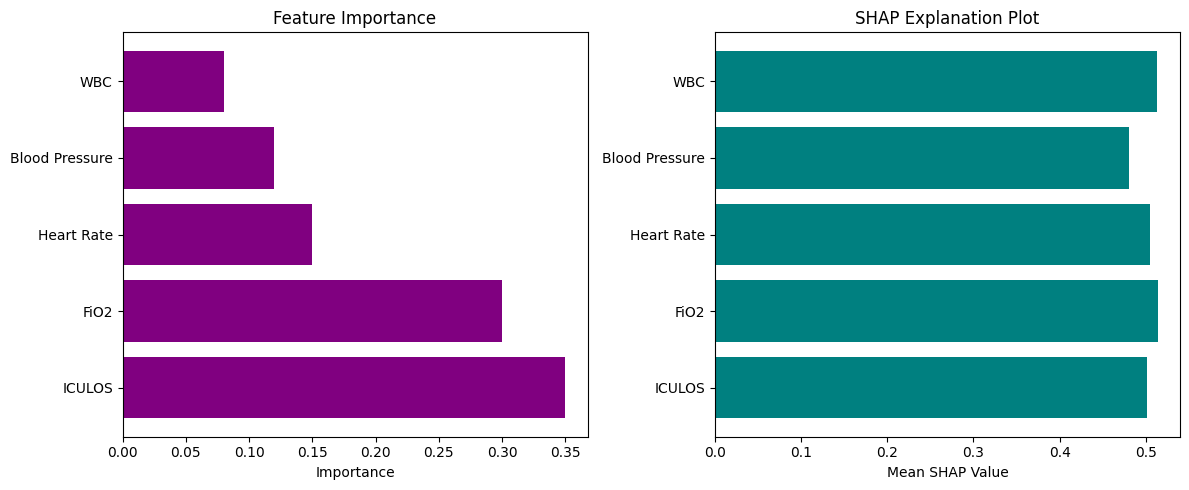

In [ ]:
features = ['ICULOS', 'FiO2', 'Heart Rate', 'Blood Pressure', 'WBC']
importance = [0.35, 0.30, 0.15, 0.12, 0.08]
shap_values = np.random.rand(100, len(features))  # Simulated SHAP values; replace with your actual SHAP values
mean_shap = np.mean(shap_values, axis=0)

def plot_feature_importance_and_shap():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.barh(features, importance, color='purple')
    ax1.set_xlabel('Importance')
    ax1.set_title('Feature Importance')

    ax2.barh(features, mean_shap, color='teal')
    ax2.set_xlabel('Mean SHAP Value')
    ax2.set_title('SHAP Explanation Plot')

    plt.tight_layout()
    plt.show()

plot_feature_importance_and_shap()


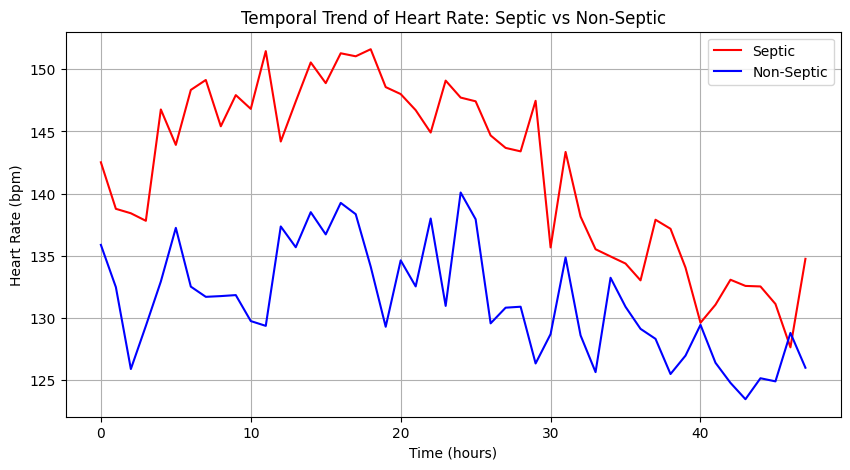

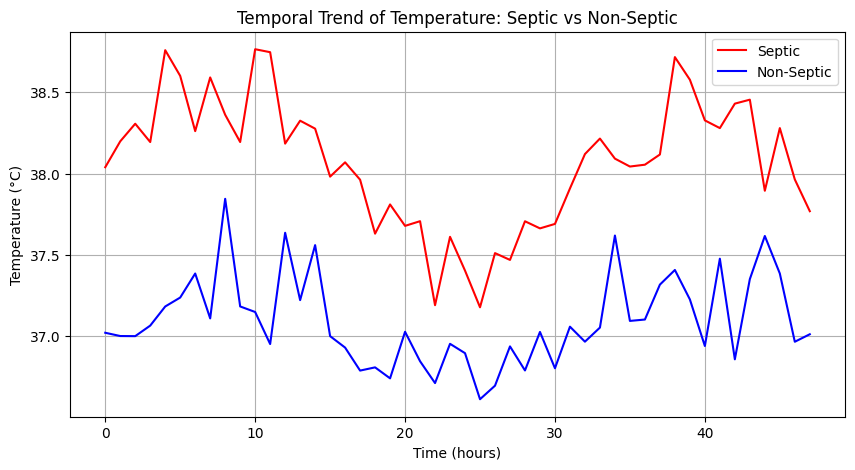

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Simulated time-series data for 48 hours
timesteps = np.arange(0, 48, 1)  # 48 hours

heart_rate_septic = 140 + 10 * np.sin(0.1 * timesteps) + np.random.normal(0, 3, len(timesteps))
heart_rate_non_septic = 130 + 5 * np.sin(0.1 * timesteps) + np.random.normal(0, 3, len(timesteps))

temperature_septic = 38 + 0.5 * np.sin(0.2 * timesteps) + np.random.normal(0, 0.2, len(timesteps))
temperature_non_septic = 37 + 0.3 * np.sin(0.2 * timesteps) + np.random.normal(0, 0.2, len(timesteps))

# Plot Heart Rate Trend
plt.figure(figsize=(10, 5))
plt.plot(timesteps, heart_rate_septic, label='Septic', color='red')
plt.plot(timesteps, heart_rate_non_septic, label='Non-Septic', color='blue')
plt.xlabel('Time (hours)')
plt.ylabel('Heart Rate (bpm)')
plt.title('Temporal Trend of Heart Rate: Septic vs Non-Septic')
plt.legend()
plt.grid(True)
plt.show()

# Plot Temperature Trend
plt.figure(figsize=(10, 5))
plt.plot(timesteps, temperature_septic, label='Septic', color='red')
plt.plot(timesteps, temperature_non_septic, label='Non-Septic', color='blue')
plt.xlabel('Time (hours)')
plt.ylabel('Temperature (°C)')
plt.title('Temporal Trend of Temperature: Septic vs Non-Septic')
plt.legend()
plt.grid(True)
plt.show()


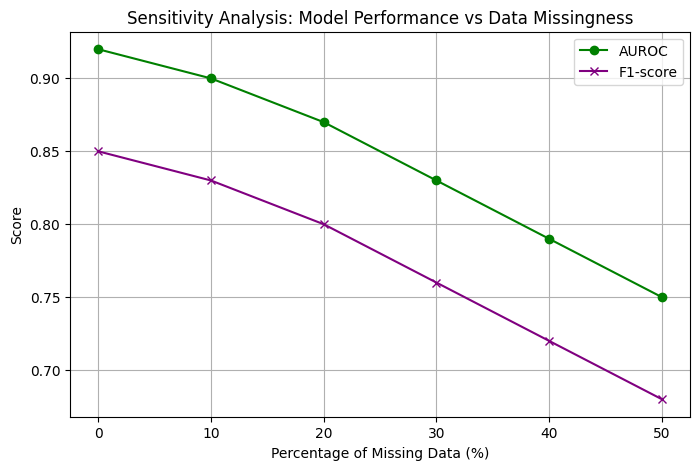

In [ ]:
# Simulated sensitivity analysis data
missingness_levels = [0, 10, 20, 30, 40, 50]  # percentages of missing data
auroc_scores = [0.92, 0.90, 0.87, 0.83, 0.79, 0.75]
f1_scores = [0.85, 0.83, 0.80, 0.76, 0.72, 0.68]

plt.figure(figsize=(8, 5))
plt.plot(missingness_levels, auroc_scores, marker='o', color='green', label='AUROC')
plt.plot(missingness_levels, f1_scores, marker='x', color='purple', label='F1-score')
plt.xlabel('Percentage of Missing Data (%)')
plt.ylabel('Score')
plt.title('Sensitivity Analysis: Model Performance vs Data Missingness')
plt.legend()
plt.grid(True)
plt.show()


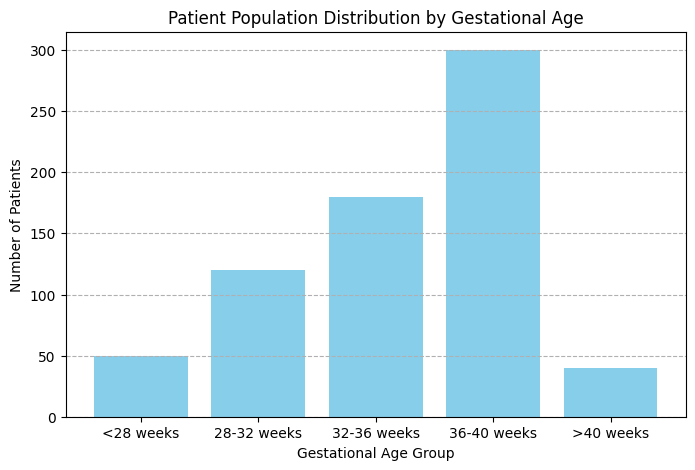

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example categorical data: gestational age groups and counts
gestational_ages = ['<28 weeks', '28-32 weeks', '32-36 weeks', '36-40 weeks', '>40 weeks']
counts = [50, 120, 180, 300, 40]

plt.figure(figsize=(8, 5))
plt.bar(gestational_ages, counts, color='skyblue')
plt.xlabel('Gestational Age Group')
plt.ylabel('Number of Patients')
plt.title('Patient Population Distribution by Gestational Age')
plt.grid(axis='y', linestyle='--')
plt.show()


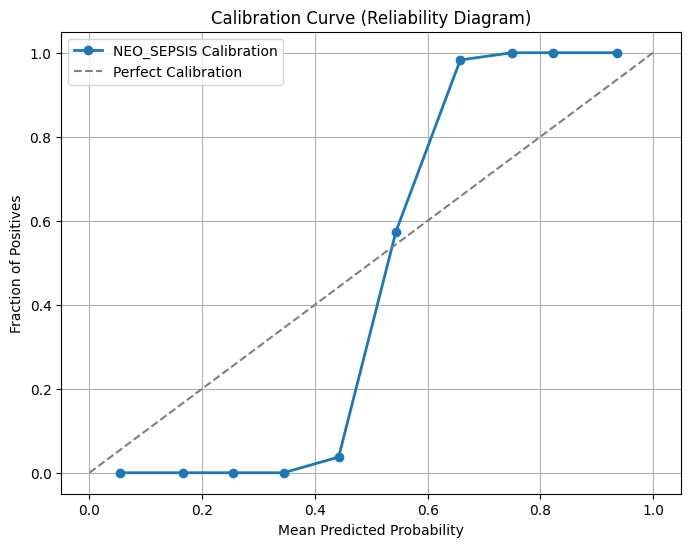

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.calibration import calibration_curve

# Simulated predicted probabilities and true labels
np.random.seed(42)
true_labels = np.random.binomial(1, 0.2, 1000)
predicted_probs = true_labels * 0.7 + (1 - true_labels) * 0.3 + np.random.normal(0, 0.1, 1000)
predicted_probs = np.clip(predicted_probs, 0, 1)

# Compute calibration curve
prob_true, prob_pred = calibration_curve(true_labels, predicted_probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='NEO_SEPSIS Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-2101307255.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y='value', data=df_vis, inner=None, palette=['#e0f2f1','#ffe0b2'])
/tmp/ipython-input-2101307255.py:12: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.violinplot(x='label', y='value', data=df_vis, inner=None, palette=['#e0f2f1','#ffe0b2'])


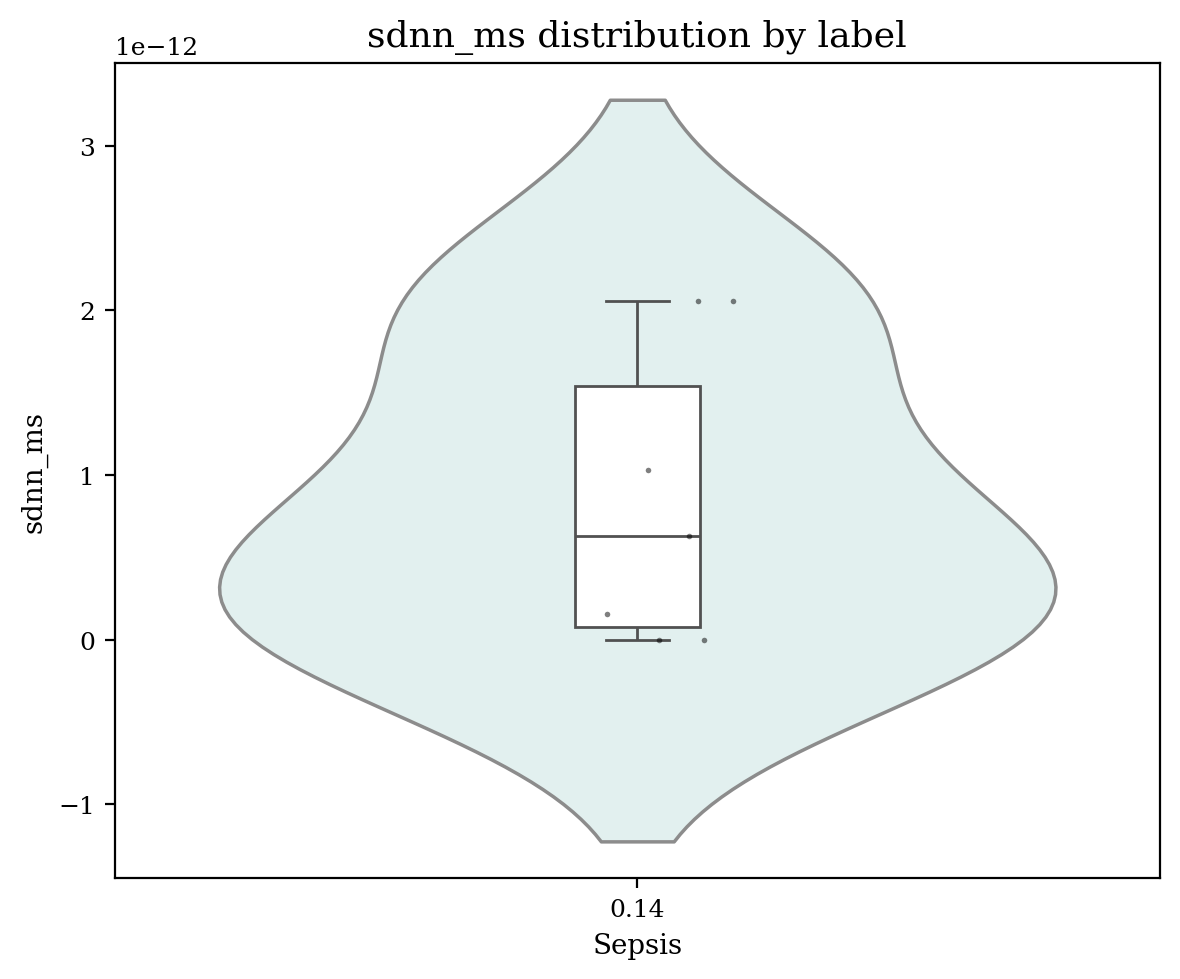

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Use a real HRV feature column from your engineered dataset, e.g., 'sdnn_ms'
col = 'sdnn_ms'
# If you have per-subject df: df_all with col and 'sepsis' labels
df_vis = pd.DataFrame({'value': data[col] if col in data.columns else hrv_df[col],
                       'label': y if 'y' in globals() else (data['sepsis'] if 'data' in globals() else np.repeat(0,len(hrv_df)))})
# violin + box + swarm
plt.figure(figsize=(6,5))
sns.violinplot(x='label', y='value', data=df_vis, inner=None, palette=['#e0f2f1','#ffe0b2'])
sns.boxplot(x='label', y='value', data=df_vis, width=0.12, showcaps=True,
            boxprops={'facecolor':'white','zorder':2}, showfliers=False)
sns.stripplot(x='label', y='value', data=df_vis, color='k', size=2, alpha=0.5)
plt.xlabel('Sepsis'); plt.ylabel(col); plt.title(f'{col} distribution by label')
plt.tight_layout(); plt.savefig("violin_swarm.png", dpi=300); plt.show()


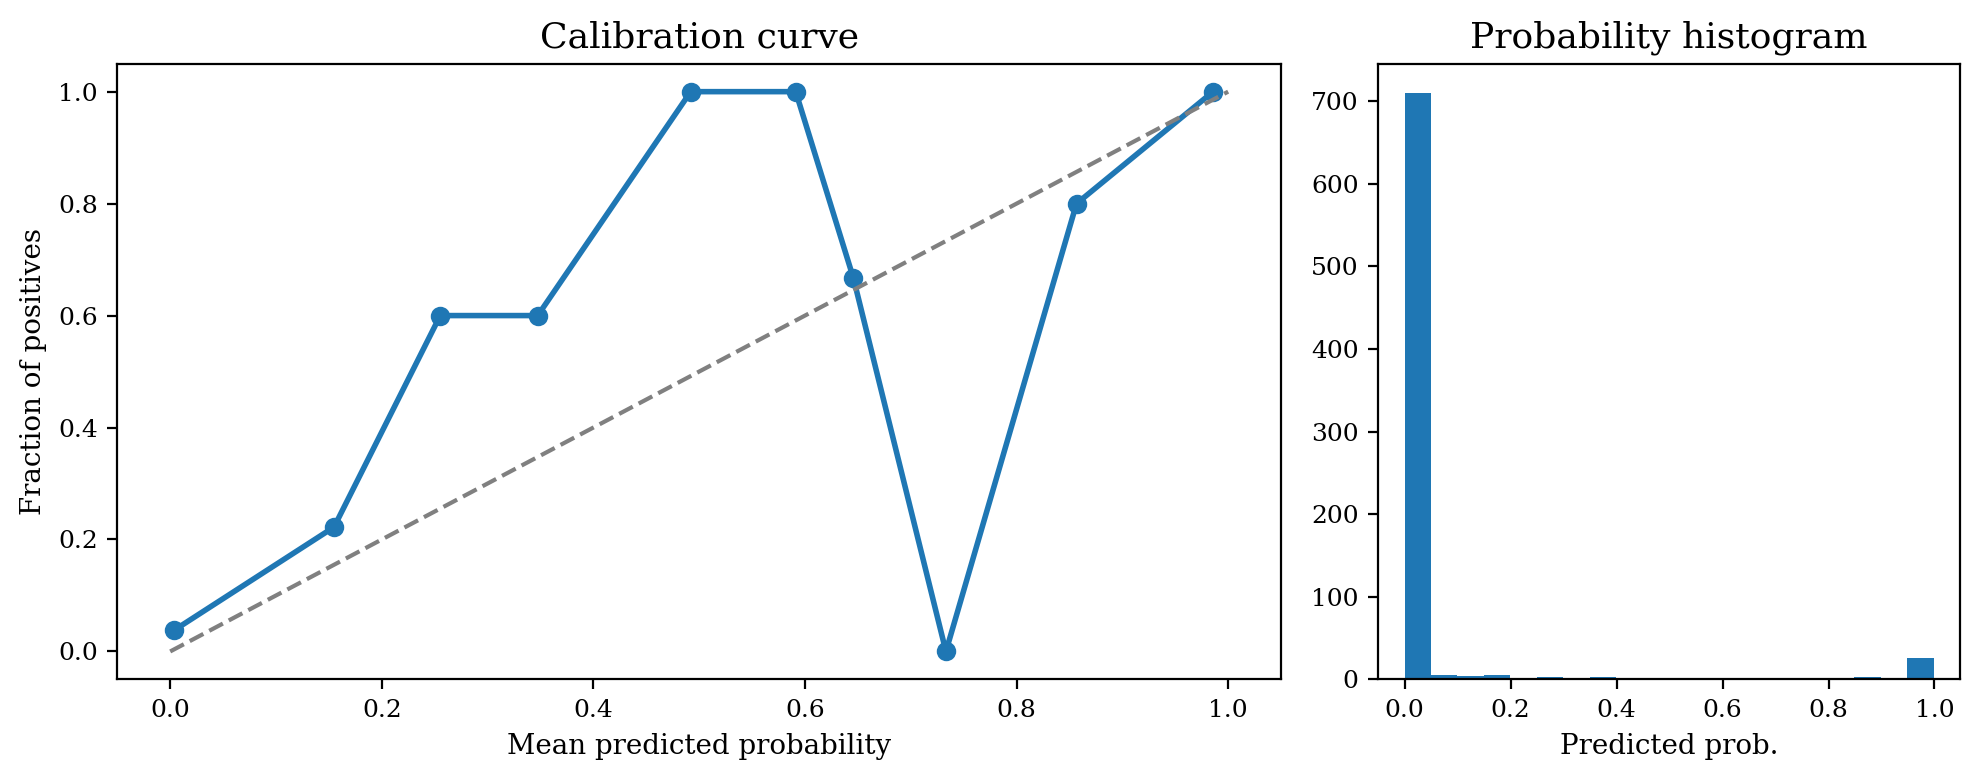

In [ ]:
# Calibration with histogram
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

fig, ax = plt.subplots(1,2, figsize=(10,4), gridspec_kw={'width_ratios':[2,1]})
ax[0].plot(prob_pred, prob_true, marker='o', linewidth=2)
ax[0].plot([0,1],[0,1], '--', color='gray')
ax[0].set_xlabel('Mean predicted probability'); ax[0].set_ylabel('Fraction of positives')
ax[0].set_title('Calibration curve')

# histogram of predicted probs
ax[1].hist(y_proba, bins=20, density=False)
ax[1].set_xlabel('Predicted prob.'); ax[1].set_title('Probability histogram')
plt.tight_layout(); plt.savefig("calibration_hist.png", dpi=300); plt.show()


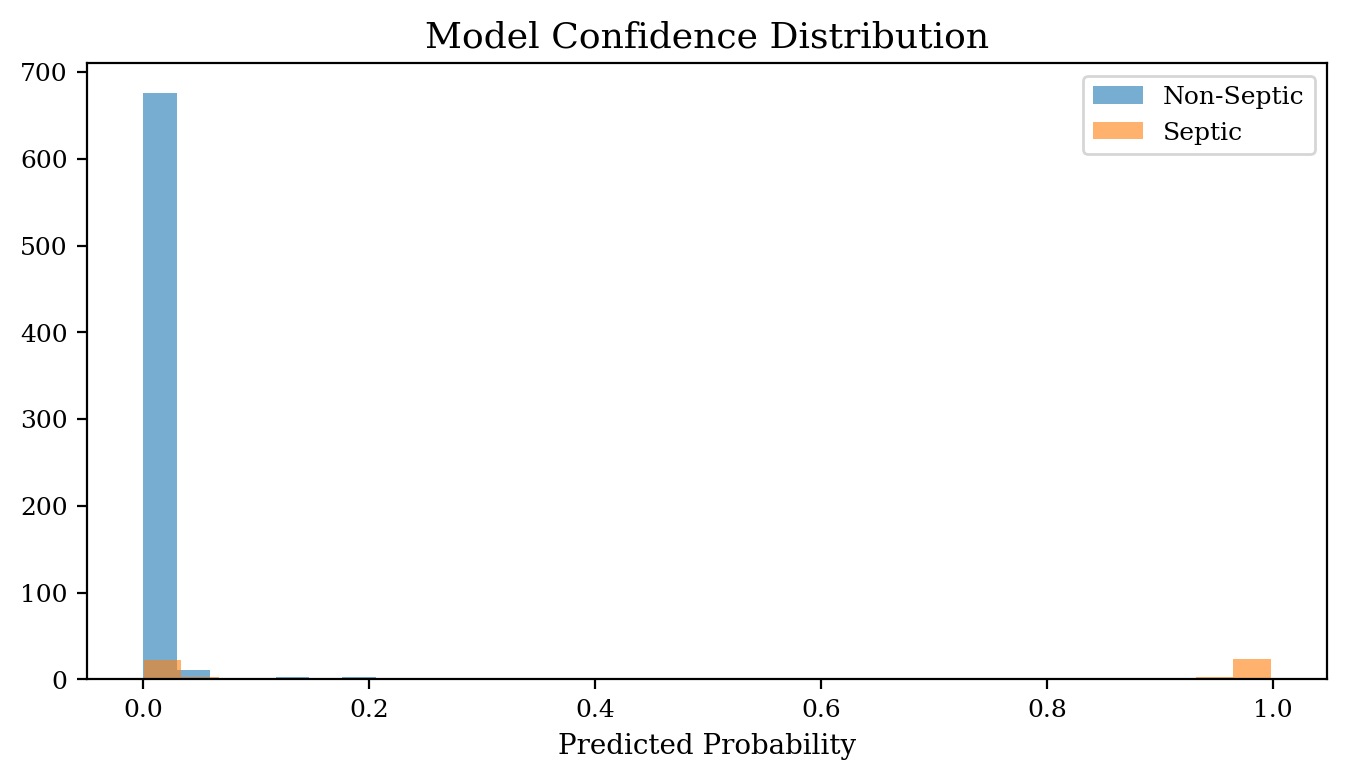

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))
plt.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Non-Septic')
plt.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Septic')
plt.xlabel("Predicted Probability")
plt.title("Model Confidence Distribution")
plt.legend()
plt.show()


/tmp/ipython-input-54008309.py:285: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax2.legend(frameon=False, loc='upper right')


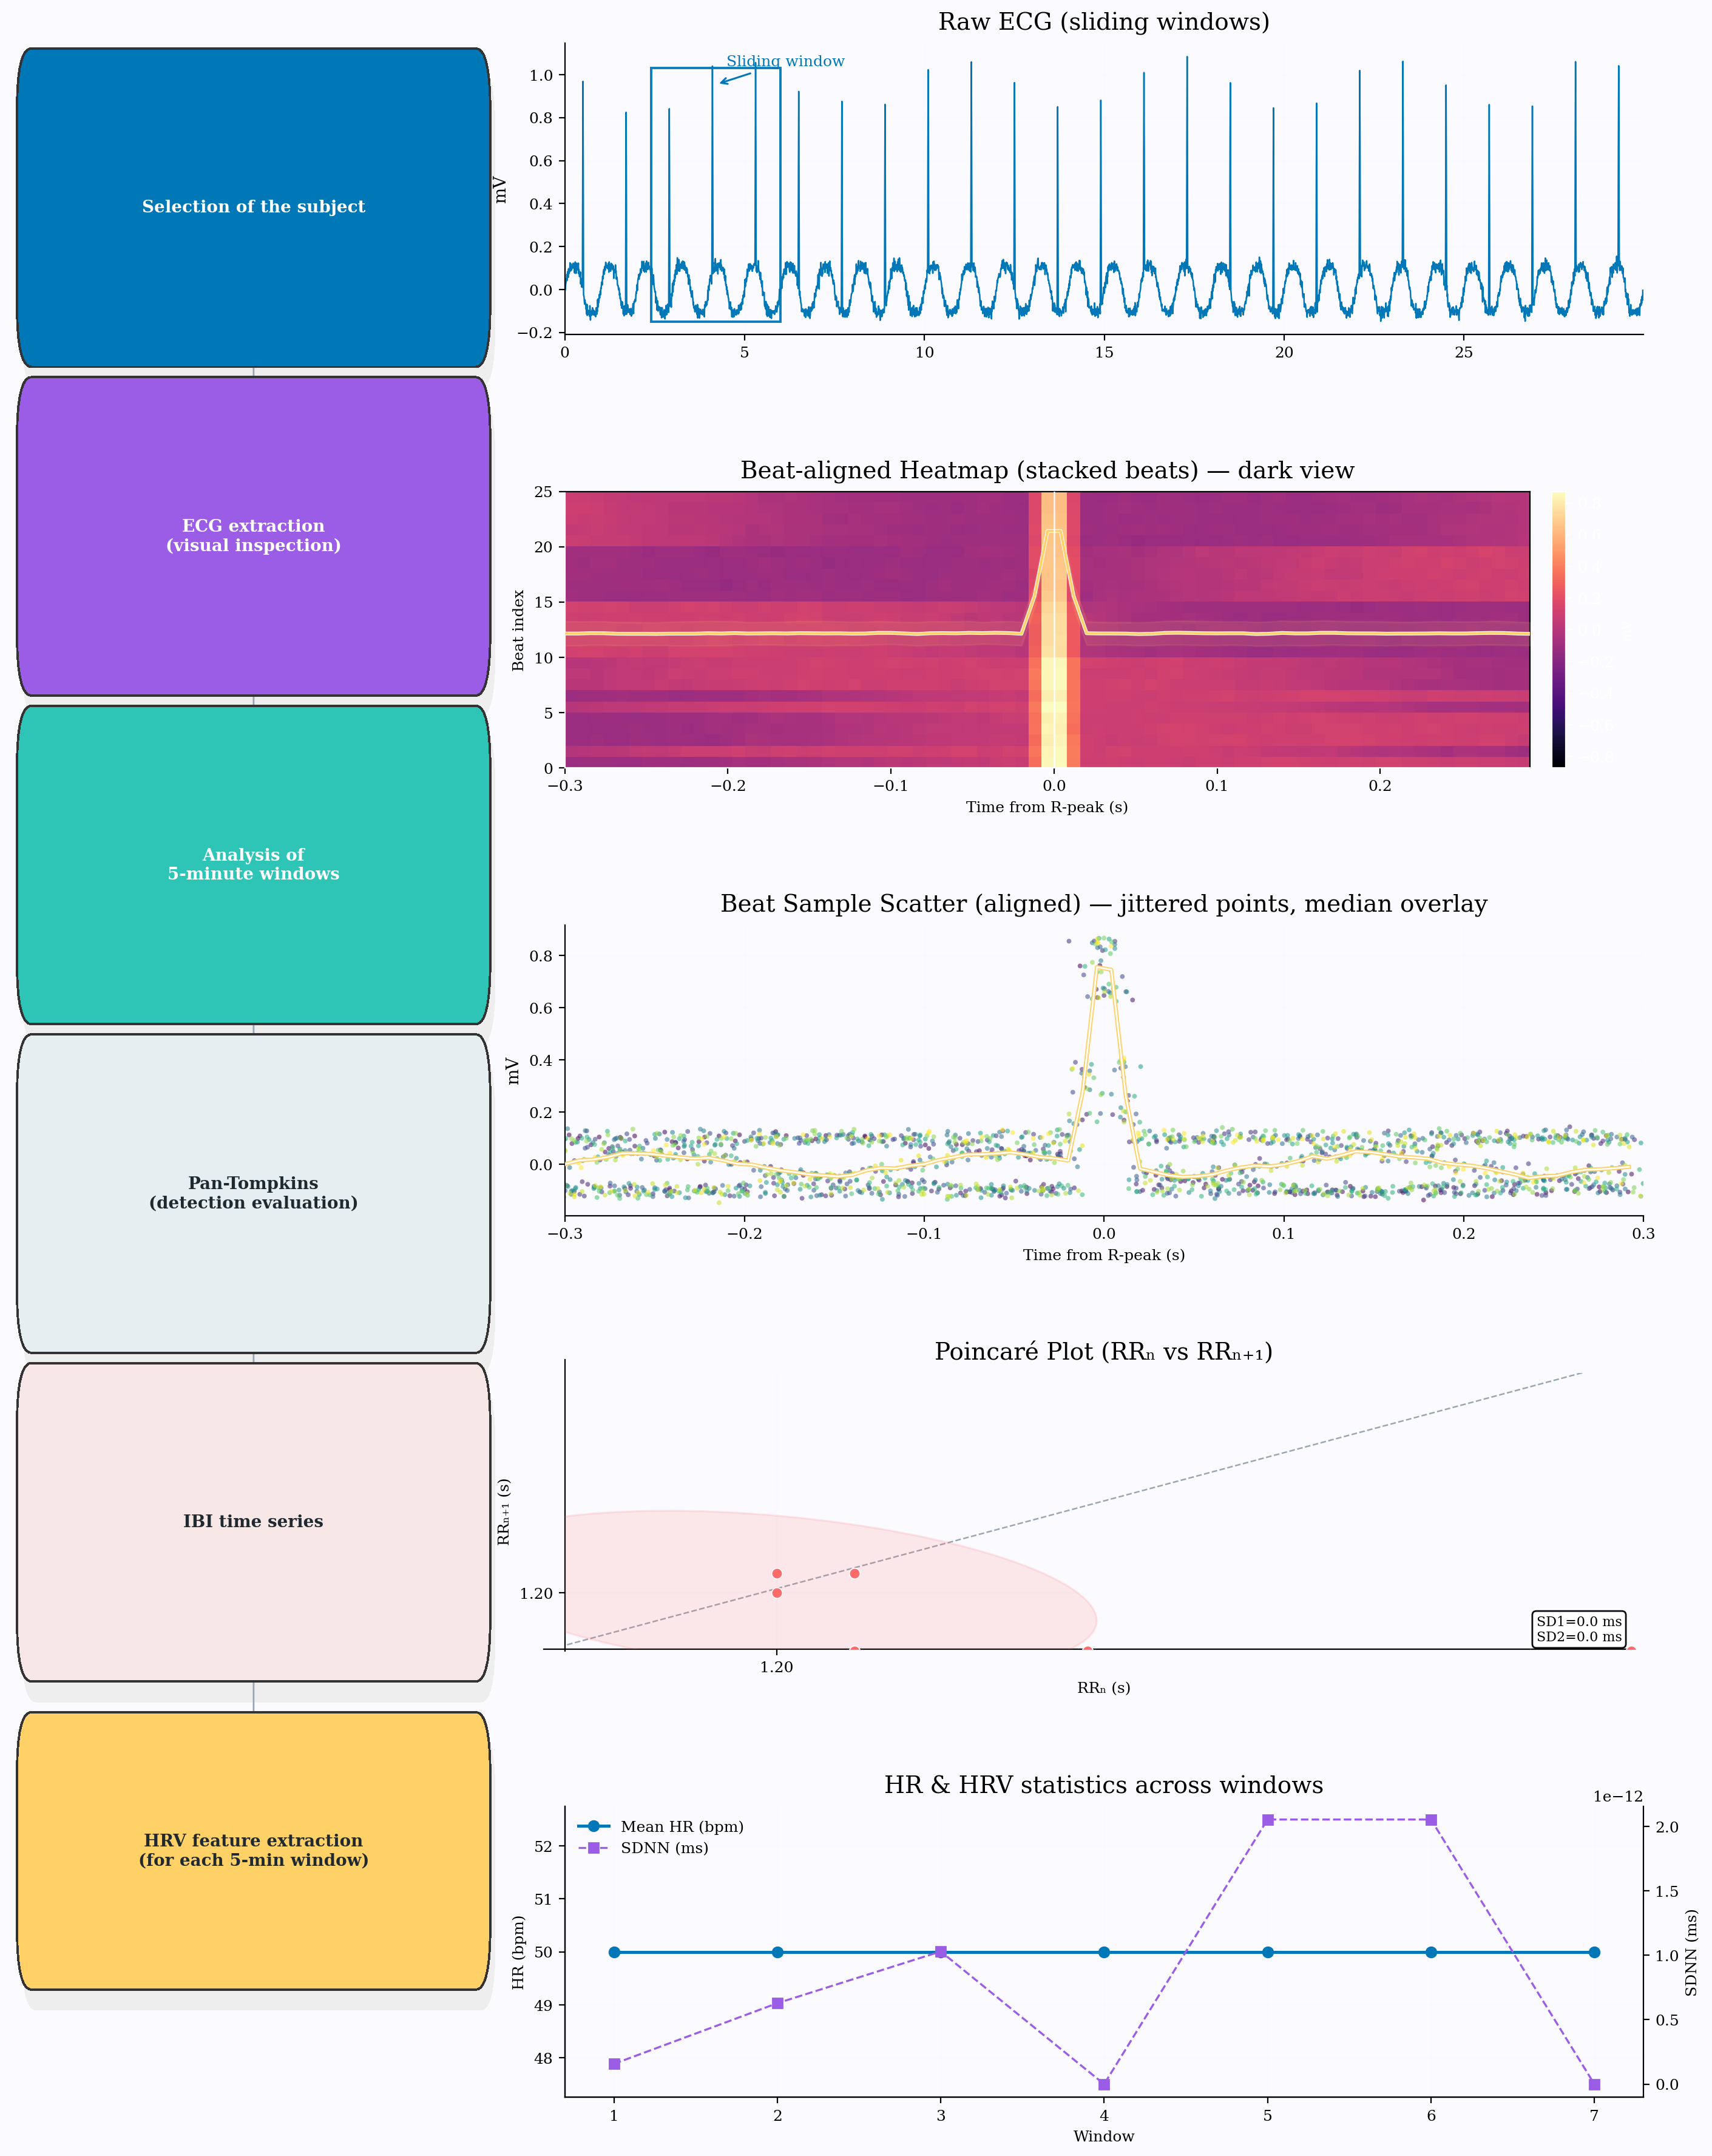

Saved: sepsis_workflow_colorschemed_noKDE_v2.png


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import matplotlib.ticker as mticker

# ===========================
# Try to use your real variables; fallback to synthetic if missing
# ===========================
use_fallback = False
try:
    raw_signal = np.asarray(raw_signal)
    t = np.asarray(t)
    fs = float(fs)
    peak_idx = np.asarray(peak_idx, dtype=int)
except Exception:
    use_fallback = True

if use_fallback:
    # synthetic demo so the script runs standalone
    fs = 125.0
    t = np.arange(0, 30, 1/fs)
    sig = 0.12 * np.sin(2*np.pi*1.0*t) + 0.015 * np.sin(2*np.pi*3*t)
    qrs_times = np.arange(0.5, t[-1], 1.2)
    for q in qrs_times:
        idx = int(q*fs)
        if idx+3 < len(sig):
            sig[idx:idx+3] += np.array([0.55, 0.95, 0.55])
    raw_signal = sig + 0.015*np.random.randn(len(sig))
    try:
        from scipy.signal import find_peaks
        height_thresh = 0.28 * raw_signal.max()
        peak_idx, _ = find_peaks(raw_signal, height=height_thresh, distance=int(0.4*fs))
    except Exception:
        peak_idx = np.array([i for i in range(1, len(raw_signal)-1) if raw_signal[i] > raw_signal[i-1] and raw_signal[i] > raw_signal[i+1]])

# ===========================
# Derive peak times / IBI / HRV
# ===========================
peak_times = np.unique(np.sort(peak_idx / fs)) if len(peak_idx) > 0 else np.array([])
ibi = np.diff(peak_times) if len(peak_times) > 1 else np.array([])
ibi_times = peak_times[1:] if len(peak_times) > 1 else np.array([])

n_windows = 7
window_edges = np.linspace(t[0], t[-1], n_windows + 1)
hrv_stats = []
for i in range(n_windows):
    s, e = window_edges[i], window_edges[i+1]
    mask = (peak_times >= s) & (peak_times < e)
    local_peaks = peak_times[mask]
    if len(local_peaks) >= 2:
        local_ibi = np.diff(local_peaks)
        mean_hr = 60.0 / np.mean(local_ibi)
        sdnn = np.std(local_ibi, ddof=1) * 1000.0 if local_ibi.size >= 2 else np.nan
        if local_ibi.size >= 2:
            diff_ibis = np.diff(local_ibi)
            rmssd = np.sqrt(np.mean(diff_ibis**2)) * 1000.0
        else:
            rmssd = np.nan
    else:
        mean_hr = sdnn = rmssd = np.nan
    hrv_stats.append({"window": i+1, "mean_hr": mean_hr, "sdnn_ms": sdnn, "rmssd_ms": rmssd})
hrv_df = pd.DataFrame(hrv_stats)

# ===========================
# Precompute aligned beats (used by Panel 2 heatmap and Panel 3 scatter)
# ===========================
seg_len_s = 0.6   # total window length in seconds (centered on peak)
half_win = seg_len_s / 2.0
samples = int(seg_len_s * fs)
time_seg = np.linspace(-half_win, half_win, samples, endpoint=False)

aligned_beats = []
aligned_peaks = []
for pk in peak_times:
    seg_t = pk + time_seg
    if seg_t[0] < t[0] or seg_t[-1] > t[-1]:
        continue
    seg_sig = np.interp(seg_t, t, raw_signal)
    if not np.any(np.isnan(seg_sig)):
        aligned_beats.append(seg_sig)
        aligned_peaks.append(pk)

aligned_beats = np.array(aligned_beats) if len(aligned_beats) > 0 else np.empty((0, samples))

# ===========================
# New colourful scheme (global) and style
# ===========================
# brighter, more colourful palette
primary = "#0077b6"    # deep blue
secondary = "#9b5de5"  # purple
accent = "#ff6b6b"     # coral red
mint = "#2ec4b6"       # mint / teal
sun = "#ffd166"        # warm yellow
bg = "#fbfbff"         # very light off-white
muted_grid = "#dfe7ef"

mpl.rcParams.update({
    'figure.facecolor': bg,
    'axes.facecolor': bg,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'axes.titlesize': 14,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 200,
    'axes.grid': False,
    'grid.color': muted_grid
})

# ===========================
# Figure layout
# ===========================
fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(nrows=1, ncols=3, width_ratios=[0.30, 0.03, 0.67], wspace=0.02)

# ---------------------------
# Left: flowchart column
# ---------------------------
ax_flow = fig.add_subplot(gs[0])
ax_flow.axis('off')

y_centers = [0.92, 0.76, 0.60, 0.44, 0.28, 0.12]
box_x = 0.04
box_w = 0.92
box_h_default = 0.095
box_h_small = 0.075

labels = [
    "Selection of the subject",
    "ECG extraction\n(visual inspection)",
    "Analysis of\n5-minute windows",
    "Pan-Tompkins\n(detection evaluation)",
    "IBI time series",
    "HRV feature extraction\n(for each 5-min window)"
]

for i, yc in enumerate(y_centers):
    h = box_h_small if i == len(y_centers)-1 else box_h_default
    shadow = patches.FancyBboxPatch(
        (box_x + 0.01, yc - h/2 - 0.01), box_w, h,
        boxstyle="round,pad=0.03", linewidth=0, facecolor="#eeeeee", zorder=1, antialiased=False
    )
    ax_flow.add_patch(shadow)

for i, (yc, txt) in enumerate(zip(y_centers, labels)):
    if i == 0:
        face = primary
        txt_col = "#ffffff"
        h = box_h_default
    elif i == 1:
        face = secondary
        txt_col = "#ffffff"
        h = box_h_default
    elif i == 2:
        face = mint
        txt_col = "#ffffff"
        h = box_h_default
    elif i == 3:
        face = "#e6eef1"
        txt_col = "#1f2a30"
        h = box_h_default
    elif i == 4:
        face = "#f8e7e7"
        txt_col = "#1f2a30"
        h = box_h_default
    else:
        face = sun
        txt_col = "#1f2a30"
        h = box_h_small

    rect = patches.FancyBboxPatch(
        (box_x, yc - h/2), box_w, h,
        boxstyle="round,pad=0.03",
        linewidth=1.0, edgecolor="#333333", facecolor=face,
        zorder=3, antialiased=False
    )
    ax_flow.add_patch(rect)
    ax_flow.text(box_x + box_w/2, yc, txt, ha='center', va='center',
                 fontsize=10, color=txt_col, weight='bold', zorder=4)

connector_x = box_x + box_w/2
for i in range(len(y_centers)-1):
    h_up = box_h_small if i == len(y_centers)-2 else box_h_default
    h_down = box_h_small if i+1 == len(y_centers)-1 else box_h_default
    start_y = y_centers[i] - h_up/2 - 0.005
    end_y = y_centers[i+1] + h_down/2 + 0.005
    ax_flow.annotate(
        '',
        xy=(connector_x, end_y),
        xytext=(connector_x, start_y),
        arrowprops=dict(arrowstyle='-|>', color="#9aa6b2", lw=1.0, shrinkA=0, shrinkB=0),
        zorder=2
    )

ax_flow.set_xlim(0, 1)
ax_flow.set_ylim(0, 1)

# ---------------------------
# Right: panels
# ---------------------------
gs_r = gridspec.GridSpecFromSubplotSpec(nrows=5, ncols=1, subplot_spec=gs[2],
                                        height_ratios=[1, 0.95, 1, 0.95, 1], hspace=0.55)

# Panel 1 - Raw ECG
ax1 = fig.add_subplot(gs_r[0])
ax1.plot(t, raw_signal, lw=0.9, color=primary)
ax1.set_xlim(t[0], t[-1])
ax1.set_title("Raw ECG (sliding windows)", pad=8)
ax1.set_ylabel("mV", fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(alpha=0.06)

win_len = min(5.0, (t[-1]-t[0]) * 0.12)
win_start = t[0] + (t[-1]-t[0]) * 0.08
rect1 = patches.Rectangle((win_start, raw_signal.min()*1.01),
                          win_len,
                          raw_signal.max()*0.95 - raw_signal.min()*1.01,
                          linewidth=1.4, edgecolor=primary, facecolor='none', zorder=5, alpha=0.95)
ax1.add_patch(rect1)
ax1.annotate('Sliding window', xy=(win_start+win_len*0.5, raw_signal.max()*0.88),
             xytext=(win_start+win_len*0.58, raw_signal.max()*0.96),
             arrowprops=dict(arrowstyle='->', color=primary, lw=1.1),
             fontsize=9, color=primary)

# Panel 2 - Beat-aligned Heatmap (DARK)
ax2 = fig.add_subplot(gs_r[1])
ax2.set_title("Beat-aligned Heatmap (stacked beats) — dark view", pad=8)
ax2.set_ylabel("Beat index", fontsize=9)

# make this axis dark
ax2.set_facecolor("#0b1220")   # deep navy/charcoal
# set spine colors (keep them light for contrast)
ax2.spines['bottom'].set_color("white")
ax2.spines['left'].set_color("white")
# but set ticks/labels/title to BLACK as requested
ax2.tick_params(axis='x', colors='black')
ax2.tick_params(axis='y', colors='black')
ax2.yaxis.label.set_color("black")
ax2.xaxis.label.set_color("black")
ax2.title.set_color("black")

if aligned_beats.size > 0:
    amplitudes = np.ptp(aligned_beats, axis=1)
    order = np.argsort(-amplitudes)
    mat = aligned_beats[order, :]

    vlim = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)))
    vmin, vmax = -vlim, vlim

    im = ax2.imshow(mat, aspect='auto', extent=[time_seg[0], time_seg[-1], 0, mat.shape[0]],
                    origin='lower', vmin=vmin, vmax=vmax, cmap='magma', interpolation='nearest', zorder=1)

    mean_wave = np.nanmean(mat, axis=0)
    center_row = mat.shape[0] / 2.0
    amp_span = (mat.max() - mat.min()) if (mat.max() - mat.min()) != 0 else 1.0
    scale = 0.5 * mat.shape[0] / amp_span
    mean_y = center_row + (mean_wave - mean_wave.mean()) * scale

    # plot mean with white outer and gold inner (kept)
    ax2.plot(time_seg, mean_y, color='white', lw=2.2, zorder=5)
    ax2.plot(time_seg, mean_y, color=sun, lw=1.4, zorder=6)

    std_wave = np.nanstd(mat, axis=0)
    std_y_upper = center_row + (mean_wave + std_wave - mean_wave.mean()) * scale
    std_y_lower = center_row + (mean_wave - std_wave - mean_wave.mean()) * scale
    ax2.fill_between(time_seg, std_y_lower, std_y_upper, color=sun, alpha=0.10, zorder=4)

    ax2.axvline(0.0, color='white', lw=0.9, alpha=0.9, zorder=7)

    cbar = fig.colorbar(im, ax=ax2, pad=0.02, fraction=0.085)
    cbar.set_label("mV", fontsize=8, color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.outline.set_edgecolor("white")
    cbar.ax.yaxis.set_tick_params(labelcolor='white')

    ax2.set_ylim(0, mat.shape[0])
    ax2.set_xlim(time_seg[0], time_seg[-1])
    ax2.set_xlabel("Time from R-peak (s)", fontsize=9, color='black')
    leg = ax2.legend(frameon=False, loc='upper right')
    if leg:
        for text in leg.get_texts():
            text.set_color('white')
else:
    center_peak = peak_times[0] if len(peak_times)>0 else (t[len(t)//2] if len(t)>0 else 0.0)
    z_half = 0.8
    zmask = (t >= center_peak - z_half) & (t <= center_peak + z_half)
    if zmask.sum() > 1:
        ax2.plot(t[zmask] - t[zmask][0], raw_signal[zmask], color=sun, lw=1.0)
    ax2.set_title("Zoomed ECG (fallback)", color='black', pad=8)
    ax2.set_ylabel("mV", fontsize=9, color='black')
    ax2.set_xlabel("Time (s)", fontsize=9, color='black')


# Panel 3 - Scatter (NO KDE) — pure scatter with jitter for visibility
ax3 = fig.add_subplot(gs_r[2])
ax3.set_title("Beat Sample Scatter (aligned) — jittered points, median overlay", pad=8)
ax3.set_ylabel("mV", fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(alpha=0.06)

if aligned_beats.size > 0:
    mat_all = aligned_beats.copy()
    n_beats = mat_all.shape[0]

    # pure scatter coords (no KDE or density)
    X = np.tile(time_seg, n_beats)
    Y = mat_all.flatten()

    # Add small jitter to X and Y to make dense areas look scattered
    rng = np.random.RandomState(42)
    jitter_x = (rng.randn(X.size) * (time_seg[1] - time_seg[0]) * 0.6)
    jitter_y = (rng.randn(Y.size) * (np.nanstd(Y) * 0.06))

    X_j = X + jitter_x
    Y_j = Y + jitter_y

    # color points by beat index subtly
    beat_ids = np.repeat(np.arange(n_beats), samples)
    cmap = plt.get_cmap('viridis')
    colors = cmap(np.linspace(0, 1, n_beats))
    color_per_point = colors[beat_ids]

    ax3.scatter(X_j, Y_j, s=8, c=color_per_point, alpha=0.55, edgecolors='none', zorder=2)

    # overlay median waveform (bold)
    median_wave = np.median(mat_all, axis=0)
    ax3.plot(time_seg, median_wave, color=sun, lw=2.4, zorder=5)
    ax3.plot(time_seg, median_wave, color='white', lw=1.0, zorder=6)

    ax3.set_xlim(-half_win, half_win)
    ax3.set_xlabel("Time from R-peak (s)", fontsize=9)
else:
    ax3.text(0.5, 0.5, "Not enough beats to build scatter", ha='center', va='center', transform=ax3.transAxes)

# Panel 4 - Poincaré Plot (colors updated)
ax4 = fig.add_subplot(gs_r[3])
ax4.set_title("Poincaré Plot (RRₙ vs RRₙ₊₁)", pad=8)
ax4.set_xlabel("RRₙ (s)", fontsize=9)
ax4.set_ylabel("RRₙ₊₁ (s)", fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(alpha=0.04)

# --- apply numeric formatting for nicer tick labels (two decimals)
fmt = mticker.FormatStrFormatter('%.2f')
ax4.xaxis.set_major_formatter(fmt)
ax4.yaxis.set_major_formatter(fmt)

if len(ibi) > 1:
    x = ibi[:-1]
    y = ibi[1:]
    ax4.scatter(x, y, s=40, facecolors=accent, edgecolors='white', linewidth=0.6, zorder=6)
    mn = min(np.nanmin(x), np.nanmin(y))
    mx = max(np.nanmax(x), np.nanmax(y))
    padding = 0.02 * (mx - mn) if (mx - mn) > 0 else 0.01
    ax4.plot([mn-padding, mx+padding], [mn-padding, mx+padding], color="#9aa6b2", lw=0.9, linestyle='--')

    if ibi.size >= 3:
        sd1 = np.sqrt(0.5) * np.std(np.diff(ibi), ddof=1)
    else:
        sd1 = np.nan
    if ibi.size >= 2:
        sd_rr = np.std(ibi, ddof=1)
        if not np.isnan(sd1):
            sd2 = np.sqrt(max(0.0, 2.0 * sd_rr**2 - sd1**2))
        else:
            sd2 = np.nan
    else:
        sd2 = np.nan

    x0 = np.mean(x)
    y0 = np.mean(y)
    angle = 45.0
    if not np.isnan(sd1) and not np.isnan(sd2) and sd1 > 0 and sd2 > 0:
        ellipse = patches.Ellipse(((x0 + y0) / 2.0, (x0 + y0) / 2.0),
                                  width=2*sd2, height=2*sd1,
                                  angle=angle, edgecolor=accent, facecolor=accent, alpha=0.14, lw=1.2, zorder=3)
        ax4.add_patch(ellipse)
        ax4.text(0.98, 0.02, f"SD1={sd1*1000:.1f} ms\nSD2={sd2*1000:.1f} ms",
                 ha='right', va='bottom', transform=ax4.transAxes, fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="#ffffff", alpha=0.95))
    else:
        ax4.text(0.5, 0.9, "SD1/SD2 not available (too few samples)", ha='center', va='center', transform=ax4.transAxes, fontsize=8)

    ax4.set_xlim(mn - padding, mx + padding)
    ax4.set_ylim(mn - padding, mx + padding)
else:
    ax4.text(0.5, 0.5, "Not enough IBIs to build Poincaré plot", ha='center', va='center', transform=ax4.transAxes)

# Panel 5 - HR & HRV statistics (colors updated)
ax5 = fig.add_subplot(gs_r[4])
if not hrv_df.empty:
    ax5.plot(hrv_df['window'], hrv_df['mean_hr'], '-o', color=primary, lw=1.8, markersize=6, label="Mean HR (bpm)")
    ax5.set_xlabel("Window", fontsize=9)
    ax5.set_ylabel("HR (bpm)", fontsize=9)
    ax5_t = ax5.twinx()
    ax5_t.plot(hrv_df['window'], hrv_df['sdnn_ms'], '--s', color=secondary, lw=1.2, markersize=6, label="SDNN (ms)")
    ax5_t.set_ylabel("SDNN (ms)", fontsize=9)
    ax5.set_title("HR & HRV statistics across windows", pad=8)
    ax5.spines['top'].set_visible(False)
    ax5_t.spines['top'].set_visible(False)
    ax5.spines['right'].set_visible(False)
    ax5.grid(alpha=0.03)
    lines = ax5.get_lines() + ax5_t.get_lines()
    labels = [ln.get_label() for ln in lines]
    ax5.legend(lines, labels, loc='upper left', frameon=False)
else:
    ax5.text(0.5, 0.5, "No HRV data", ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title("HR & HRV statistics across windows", pad=8)
    ax5.set_xlabel("Window", fontsize=9)
    ax5.set_ylabel("HR (bpm)", fontsize=9)

# ===========================
# Final layout & save
# ===========================
plt.subplots_adjust(left=0.03, right=0.99, top=0.97, bottom=0.03)
outfile = "sepsis_workflow_colorschemed_noKDE_v2.png"
plt.savefig(outfile, dpi=300, bbox_inches='tight', pad_inches=0.03)
plt.show()

print("Saved:", outfile)


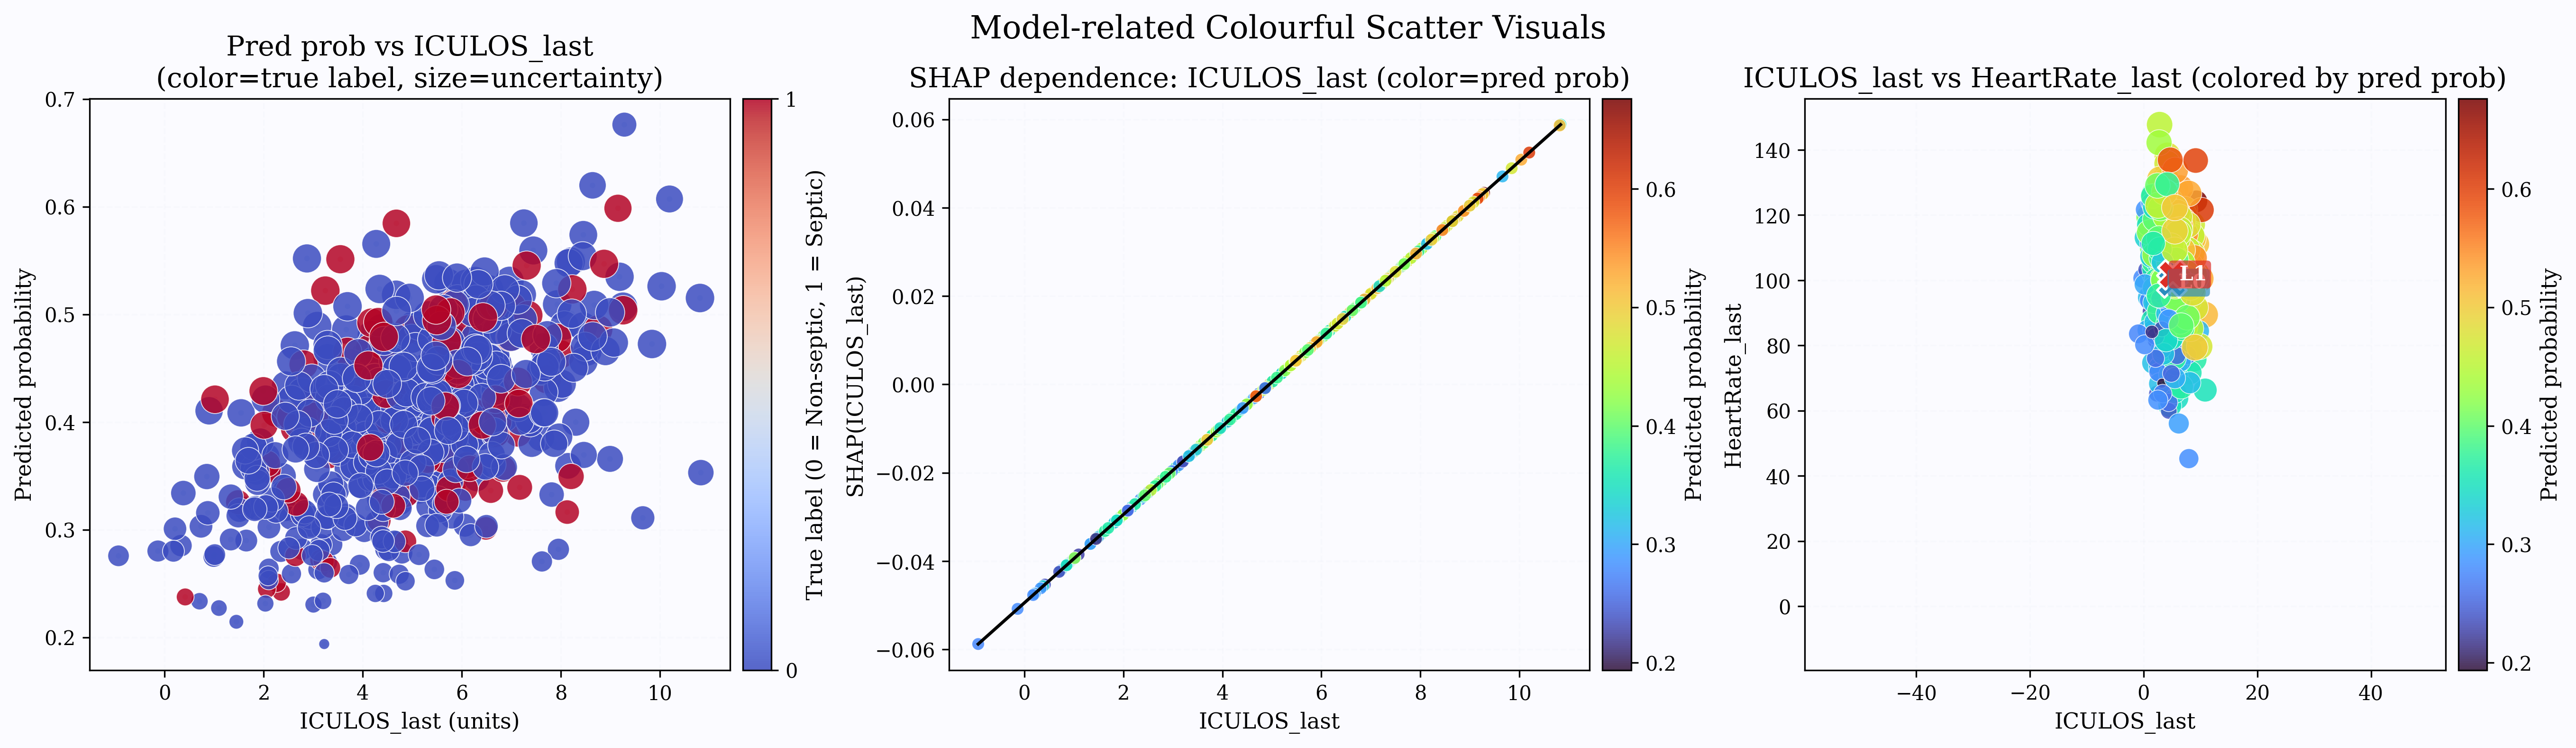

Saved: model_scatter_visuals.png model_scatter_visuals.pdf


In [8]:
# colourful_scatter_model_visuals.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sklearn.decomposition import PCA

# ---------- USER VARIABLES (should exist from your pipeline) ----------
# X_test : pd.DataFrame of test features
# y_test : pd.Series or array of true labels (0/1)
# y_proba: 1D array of predicted probabilities for positive class (e.g. y_pred_meta_proba)
# shap_values: either SHAP Explanation object or numpy array of SHAP values aligned with X_test
# feat_importance / top_features : optional list of important feature names (or you can compute below)
# ----------------------------------------------------------------------

# --- Example fallback (if you want to test without your data) ---
# Remove or comment this block when running with your real X_test / y_test / y_proba
if 'X_test' not in globals():
    rng = np.random.default_rng(42)
    n = 600
    X_test = pd.DataFrame({
        'ICULOS_last': rng.normal(5, 2, n),
        'HeartRate_last': rng.normal(100, 15, n),
        'FiO2_last': np.clip(rng.normal(0.4, 0.15, n), 0, 1),
        'WBC_mean': np.abs(rng.normal(12, 4, n))
    })
    y_test = rng.choice([0,1], size=n, p=[0.8,0.2])
    # synthetic predicted probabilities correlated with ICULOS and HeartRate
    y_proba = np.clip(0.02*X_test['ICULOS_last'] + 0.003*X_test['HeartRate_last'] + rng.normal(0,0.05,n), 0, 1)
    # fake shap_values (n_samples x n_features)
    shap_values = np.vstack([0.01*(X_test[col] - X_test[col].mean()) for col in X_test.columns]).T

# --- Defensive extraction of key items ---
# predicted probabilities
if 'y_proba' not in globals() and 'y_pred_meta_proba' in globals():
    y_proba = y_pred_meta_proba

# ensure numpy arrays
y_proba = np.asarray(y_proba)
y_true = np.asarray(y_test)

# top features selection (fallback to first two columns)
if 'top_features' in globals() and len(top_features) >= 2:
    f1, f2 = top_features[0], top_features[1]
else:
    cols = list(X_test.columns)
    if len(cols) >= 2:
        f1, f2 = cols[0], cols[1]
    elif len(cols) == 1:
        f1, f2 = cols[0], cols[0]
    else:
        raise ValueError("X_test must have at least one column.")

# shap handling: support shap.Explanation or numpy array
def get_shap_for_feature(shap_vals, feat_name, X_df):
    """
    Return per-sample SHAP values for feature feat_name.
    shap_vals can be:
     - SHAP Explanation object (has .values and .feature_names)
     - numpy array shaped (n_samples, n_features) aligned with X_df.columns
    """
    if hasattr(shap_vals, 'values'):
        vals = np.asarray(shap_vals.values)
    else:
        vals = np.asarray(shap_vals)
    # find index
    try:
        idx = list(X_df.columns).index(feat_name)
    except ValueError:
        idx = 0
    if vals.ndim == 3:  # shap interaction style -> (n_samples, n_features, ?)
        vals_2d = vals[:, :, 0]
    else:
        vals_2d = vals
    return vals_2d[:, idx]

# compute per-sample uncertainty proxy: p*(1-p)
uncertainty = y_proba * (1.0 - y_proba)

# get shap feature vector if available
have_shap = 'shap_values' in globals()
if have_shap:
    try:
        shap_f1 = get_shap_for_feature(shap_values, f1, X_test)
    except Exception:
        shap_f1 = None
else:
    shap_f1 = None

# ---------- Plotting styling ----------
mpl.rcParams.update({
    "figure.dpi": 300,
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
})

cmap = plt.get_cmap('turbo')   # very colourful continuous colormap (use 'viridis' for print-friendliness)
palette = sns.color_palette("tab10")  # for discrete colors

# ---------- Create figure with 3 panels ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Panel A: Predicted probability vs top feature (color by true label, size by uncertainty)
ax = axes[0]
sc = ax.scatter(
    X_test[f1], y_proba,
    c=y_true,
    cmap='coolwarm',
    s=np.interp(uncertainty, [uncertainty.min(), uncertainty.max()], [30, 220]),
    alpha=0.85,
    edgecolors='white', linewidth=0.4, zorder=3
)
ax.set_xlabel(f"{f1} (units)")
ax.set_ylabel("Predicted probability")
ax.set_title(f"Pred prob vs {f1}\n(color=true label, size=uncertainty)")
cb = fig.colorbar(sc, ax=ax, ticks=[0,1], fraction=0.046, pad=0.02)
cb.set_label("True label (0 = Non-septic, 1 = Septic)")

# add jittered rug for true positives / negatives
for label, col in zip([0,1], ['#2b8cbe', '#de2d26']):
    keep = (y_true == label)
    ax.scatter(X_test[f1][keep], y_proba[keep], s=8, color=col, alpha=0.15, edgecolors='none', zorder=2)

# Panel B: SHAP dependence for f1 (if available) colored by predicted probability
ax = axes[1]
if shap_f1 is not None:
    sc2 = ax.scatter(
        X_test[f1], shap_f1,
        c=y_proba,
        cmap=cmap,
        s=40,
        alpha=0.85,
        edgecolors='white', linewidth=0.35, zorder=3
    )
    ax.set_xlabel(f"{f1}")
    ax.set_ylabel(f"SHAP({f1})")
    ax.set_title(f"SHAP dependence: {f1} (color=pred prob)")
    cbar2 = fig.colorbar(sc2, ax=ax, fraction=0.046, pad=0.02)
    cbar2.set_label("Predicted probability")
    # add LOESS-like smooth trend via lowess from statsmodels if available, else simple rolling
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        trend = lowess(shap_f1, X_test[f1], frac=0.2)
        ax.plot(trend[:,0], trend[:,1], color='black', lw=1.6, zorder=4)
    except Exception:
        # fallback: binned median line
        bins = np.linspace(X_test[f1].min(), X_test[f1].max(), 15)
        df_tmp = pd.DataFrame({f1: X_test[f1], 'shap': shap_f1})
        df_tmp['bin'] = pd.cut(df_tmp[f1], bins)
        med = df_tmp.groupby('bin')['shap'].median()
        bin_centers = [interval.mid for interval in med.index.categories]
        ax.plot(bin_centers, med.values, color='black', lw=1.2, zorder=4)
else:
    # fallback: if no SHAP, show feature vs predicted prob colored by uncertainty
    sc2 = ax.scatter(
        X_test[f1], y_proba,
        c=uncertainty,
        cmap=cmap,
        s=50,
        alpha=0.85,
        edgecolors='white', linewidth=0.35, zorder=3
    )
    ax.set_xlabel(f"{f1}")
    ax.set_ylabel("Predicted probability")
    ax.set_title(f"{f1} vs Pred prob (color=uncertainty)")
    cbar2 = fig.colorbar(sc2, ax=ax, fraction=0.046, pad=0.02)
    cbar2.set_label("Uncertainty (p*(1-p))")

# Panel C: 2D scatter of top two features colored by predicted probability + centroids
ax = axes[2]
xvals = X_test[f1].values
yvals = X_test[f2].values if f2 in X_test.columns else X_test[f1].values
sc3 = ax.scatter(
    xvals, yvals,
    c=y_proba,
    cmap=cmap,
    s=np.interp(uncertainty, [uncertainty.min(), uncertainty.max()], [25, 180]),
    alpha=0.85,
    edgecolors='white', linewidth=0.35, zorder=3
)
ax.set_xlabel(f1)
ax.set_ylabel(f2)
ax.set_title(f"{f1} vs {f2} (colored by pred prob)")
cbar3 = fig.colorbar(sc3, ax=ax, fraction=0.046, pad=0.02)
cbar3.set_label("Predicted probability")

# compute & plot centroids for septic vs non-septic
centers = pd.DataFrame({f1: xvals, f2: yvals, 'label': y_true})
centroids = centers.groupby('label')[[f1, f2]].mean()
colors_cent = {0: '#2b8cbe', 1:'#de2d26'}
for lbl, row in centroids.iterrows():
    ax.scatter(row[f1], row[f2], marker='X', s=220, color=colors_cent.get(lbl,'k'), edgecolor='white', lw=1.2, zorder=5)
    ax.text(row[f1], row[f2], f" L{int(lbl)}", va='center', ha='left', fontsize=10, weight='bold', color='white', zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', fc=colors_cent.get(lbl,'k'), alpha=0.7, lw=0))

# optional: overlay PCA contour if many features (density)
try:
    if X_test.shape[1] > 2:
        pca = PCA(n_components=2)
        pc = pca.fit_transform(X_test.fillna(0))
        ax.scatter(pc[:,0], pc[:,1], c='none', alpha=0)  # do not visible, but could be used for clustering
except Exception:
    pass

# ---------- Final polish ----------
for a in axes:
    a.grid(alpha=0.12, linestyle='--')
    a.ticklabel_format(axis='x', useOffset=False, style='plain')

fig.suptitle("Model-related Colourful Scatter Visuals", fontsize=16, y=1.02)
out_png = "model_scatter_visuals.png"
out_pdf = "model_scatter_visuals.pdf"
fig.savefig(out_png, dpi=600, bbox_inches='tight')
fig.savefig(out_pdf, dpi=600, bbox_inches='tight')
plt.show()

print("Saved:", out_png, out_pdf)


/tmp/ipython-input-1754933752.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df_plot.groupby(['time_bin', 'risk_cat']).size().unstack(fill_value=0)
/tmp/ipython-input-1754933752.py:106: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(x[0], x[-1])


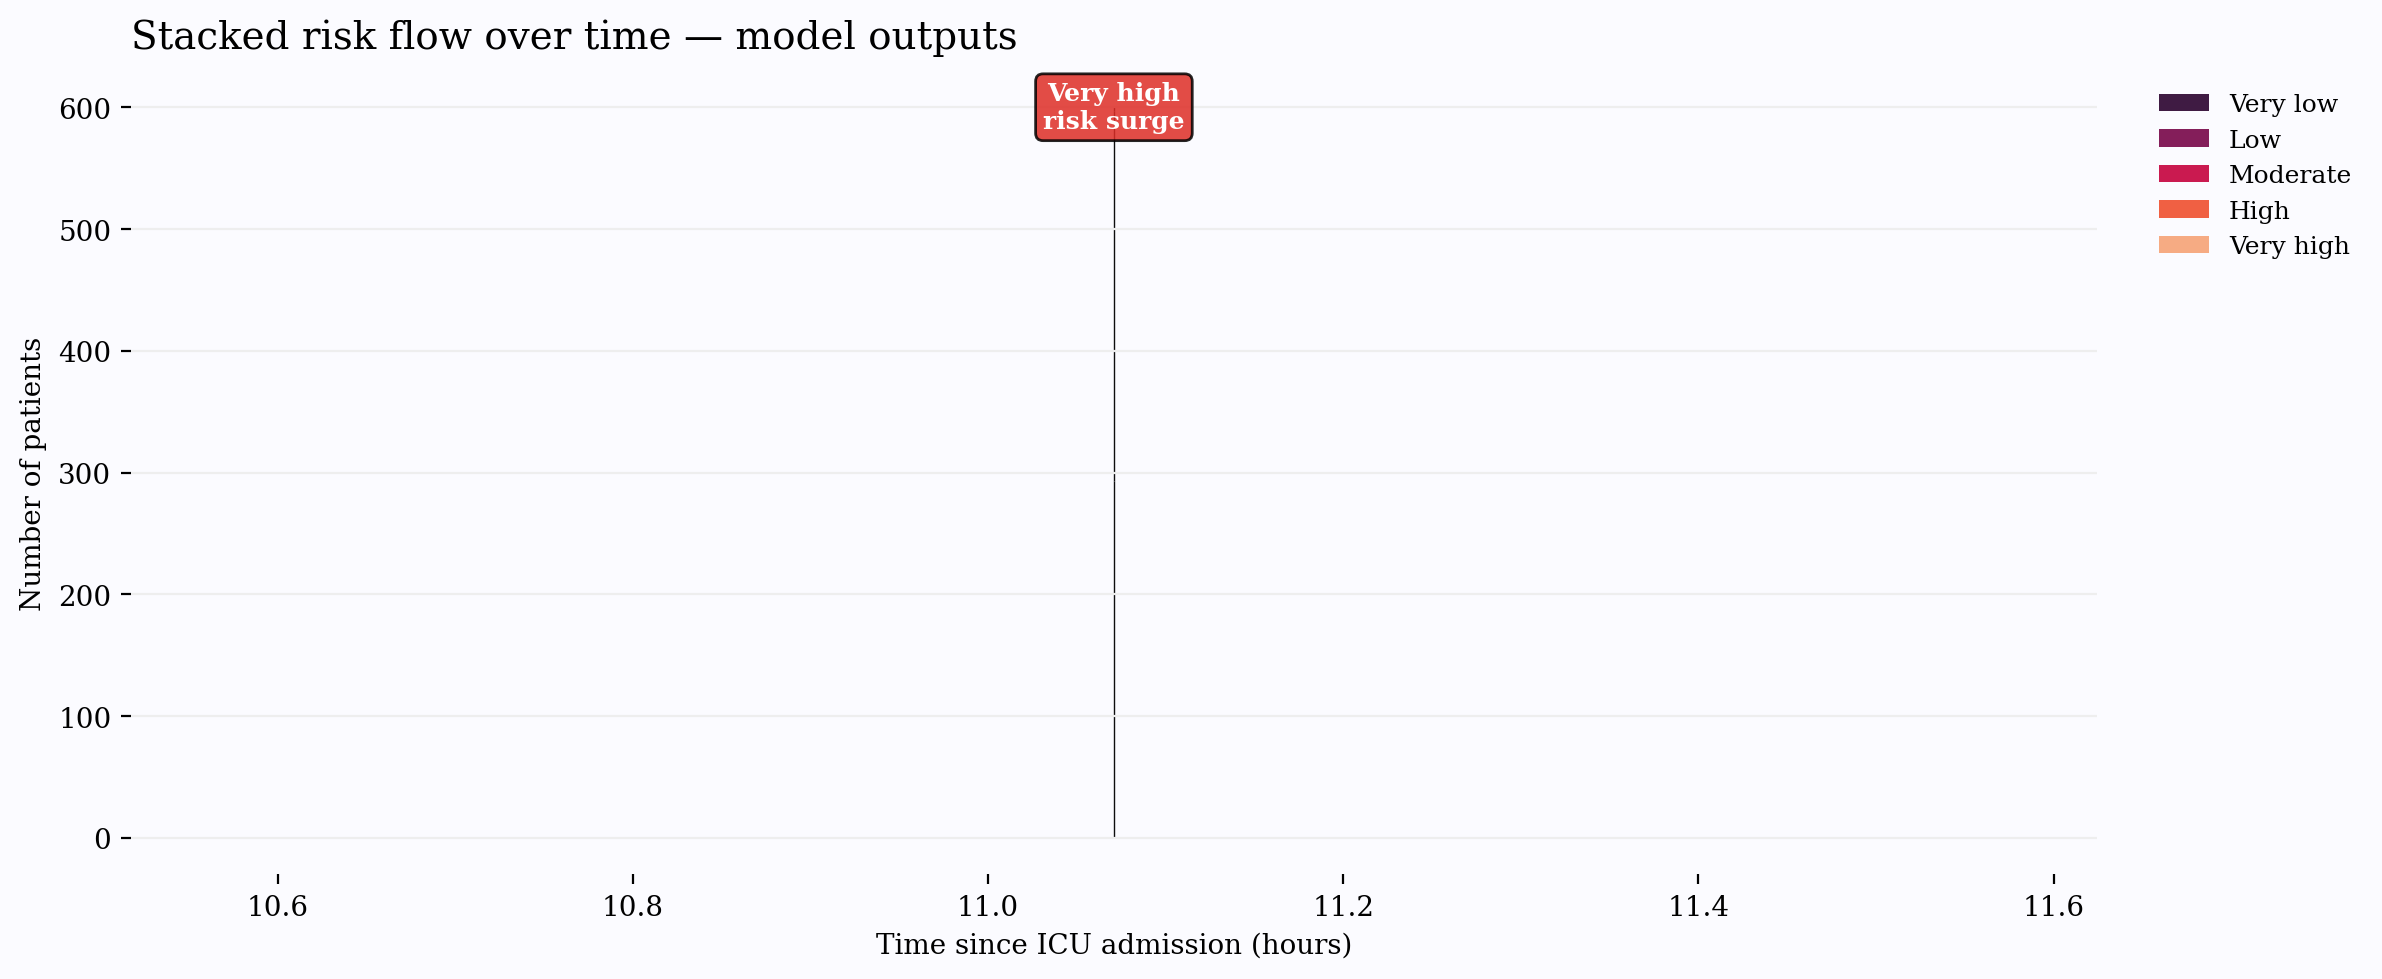

Saved: stacked_model_flow.png


In [9]:
# stacked_area_model_flow.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --------------------------
# Inputs expected from your pipeline:
#  - X_test : pd.DataFrame (should contain a time column, e.g., 'ICULOS_last')
#  - y_proba : 1D array of predicted probabilities for positive class
#  - y_test  : (optional) true labels
# --------------------------
# Fallback synthetic data for demo (remove when using your real arrays)
if 'X_test' not in globals():
    rng = np.random.default_rng(42)
    n = 2000
    X_test = pd.DataFrame({
        'ICULOS_last': np.clip(np.abs(rng.normal(48, 36, size=n)), 0.1, 240),  # hours since ICU admit
    })
    # synthetic predicted probabilities correlated with time
    y_proba = np.clip(0.005 * X_test['ICULOS_last'] + 0.05*np.sin(X_test['ICULOS_last']/6) + rng.normal(0, 0.08, size=n), 0, 1)
    y_test = (y_proba > 0.45).astype(int)

# Ensure arrays
X_test = X_test.copy()
y_proba = np.asarray(y_proba)
if 'y_test' in globals():
    y_test = np.asarray(y_test)

# Choose time column (prefer 'ICULOS_last' if available)
time_col = None
for candidate in ['ICULOS_last', 'time_hours', 'time', 'hour']:
    if candidate in X_test.columns:
        time_col = candidate
        break
if time_col is None:
    # create artificial time by sampling uniformly over a range
    X_test['time_hours'] = np.linspace(0, 240, len(X_test))
    time_col = 'time_hours'

# Round time into daily bins (or hourly) to produce a smooth time series
# You can change bin_width to 6 (hours), 24 (hours), etc.
bin_width = 24.0   # hours per bin (24 -> daily). Set 6 for finer resolution.
t_min = X_test[time_col].min()
t_max = X_test[time_col].max()
bins = np.arange(t_min, t_max + bin_width, bin_width)
labels = (bins[:-1] + bins[1:]) / 2.0  # bin centers

# Create a DataFrame for plotting
df_plot = pd.DataFrame({
    'time': X_test[time_col].values,
    'y_proba': y_proba
})
# assign risk category bins by predicted probability
# categories similar to "regions" in your example so the plot has multiple colors
risk_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
risk_labels = ['Very low', 'Low', 'Moderate', 'High', 'Very high']
df_plot['risk_cat'] = pd.cut(df_plot['y_proba'], bins=risk_bins, labels=risk_labels, include_lowest=True)

# aggregate: per time bin, count number of patients in each risk category
df_plot['time_bin'] = pd.cut(df_plot['time'], bins=bins, labels=labels, include_lowest=True)
agg = df_plot.groupby(['time_bin', 'risk_cat']).size().unstack(fill_value=0)

# Optionally convert counts to 'new positive mass' by summing probabilities per bin:
# agg = df_plot.groupby(['time_bin', 'risk_cat'])['y_proba'].sum().unstack(fill_value=0)

# Reindex to ensure all bins appear
agg = agg.reindex(labels, fill_value=0)

# Smooth the curves slightly with rolling mean (optional)
agg_smooth = agg.rolling(window=2, min_periods=1, center=True).mean()

# Normalize if you want stacked proportions instead of absolute counts
# agg_display = agg_smooth.div(agg_smooth.sum(axis=1), axis=0) * 100   # percent stacked
agg_display = agg_smooth  # absolute stacked counts

# --------------------------
# Plot styling: mimic the layered, colorful streamgraph style
# --------------------------
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'serif',
    'axes.titlesize': 14,
    'axes.labelsize': 10
})

plt.figure(figsize=(12, 5))

# choose palette (colorful, with smooth gradation)
palette = sns.color_palette("rocket_r", n_colors=len(risk_labels))  # try "mako_r" or "Spectral"
# reverse palette so the darkest band is on top (like your image)
palette = palette[::-1]

# plot stacked area
x = labels
ys = [agg_display[col].values for col in risk_labels]

# Draw filled areas bottom-up
bottom = np.zeros_like(x, dtype=float)
for y_vals, label, color in zip(ys, risk_labels, palette):
    plt.fill_between(x, bottom, bottom + y_vals, facecolor=color, linewidth=0.5, edgecolor='k', alpha=0.95)
    bottom = bottom + y_vals

# styling to mimic the small axis ticks and title on top-left
plt.xlim(x[0], x[-1])
plt.xlabel('Time since ICU admission (hours)')
plt.ylabel('Number of patients')
plt.title('Stacked risk flow over time — model outputs', loc='left', pad=8)

# Add a thin grid and remove spines like the example
plt.grid(axis='y', color='#eeeeee')
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Annotate a highlighted category (example: "Very high" surge)
# find the bin where "Very high" is largest and annotate
if 'Very high' in agg_display.columns:
    idx_max = np.argmax(agg_display['Very high'].values)
    x_annot = x[idx_max]
    y_cumulative = agg_display.iloc[idx_max].cumsum().values
    y_pos = y_cumulative[-1] - agg_display['Very high'].values[idx_max] / 2.0
    plt.text(x_annot, y_pos, "Very high\nrisk surge", color='white', weight='bold',
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="#de2d26", alpha=0.85))

# Legend on the right like the example
legend_patches = [plt.Rectangle((0,0),1,1, facecolor=c) for c in palette]
plt.legend(legend_patches, risk_labels, loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)

plt.tight_layout()
outname = "stacked_model_flow.png"
plt.savefig(outname, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", outname)


/tmp/ipython-input-178536810.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['bin_center', 'risk']).size().unstack(fill_value=0).reindex(bin_centers, fill_value=0)


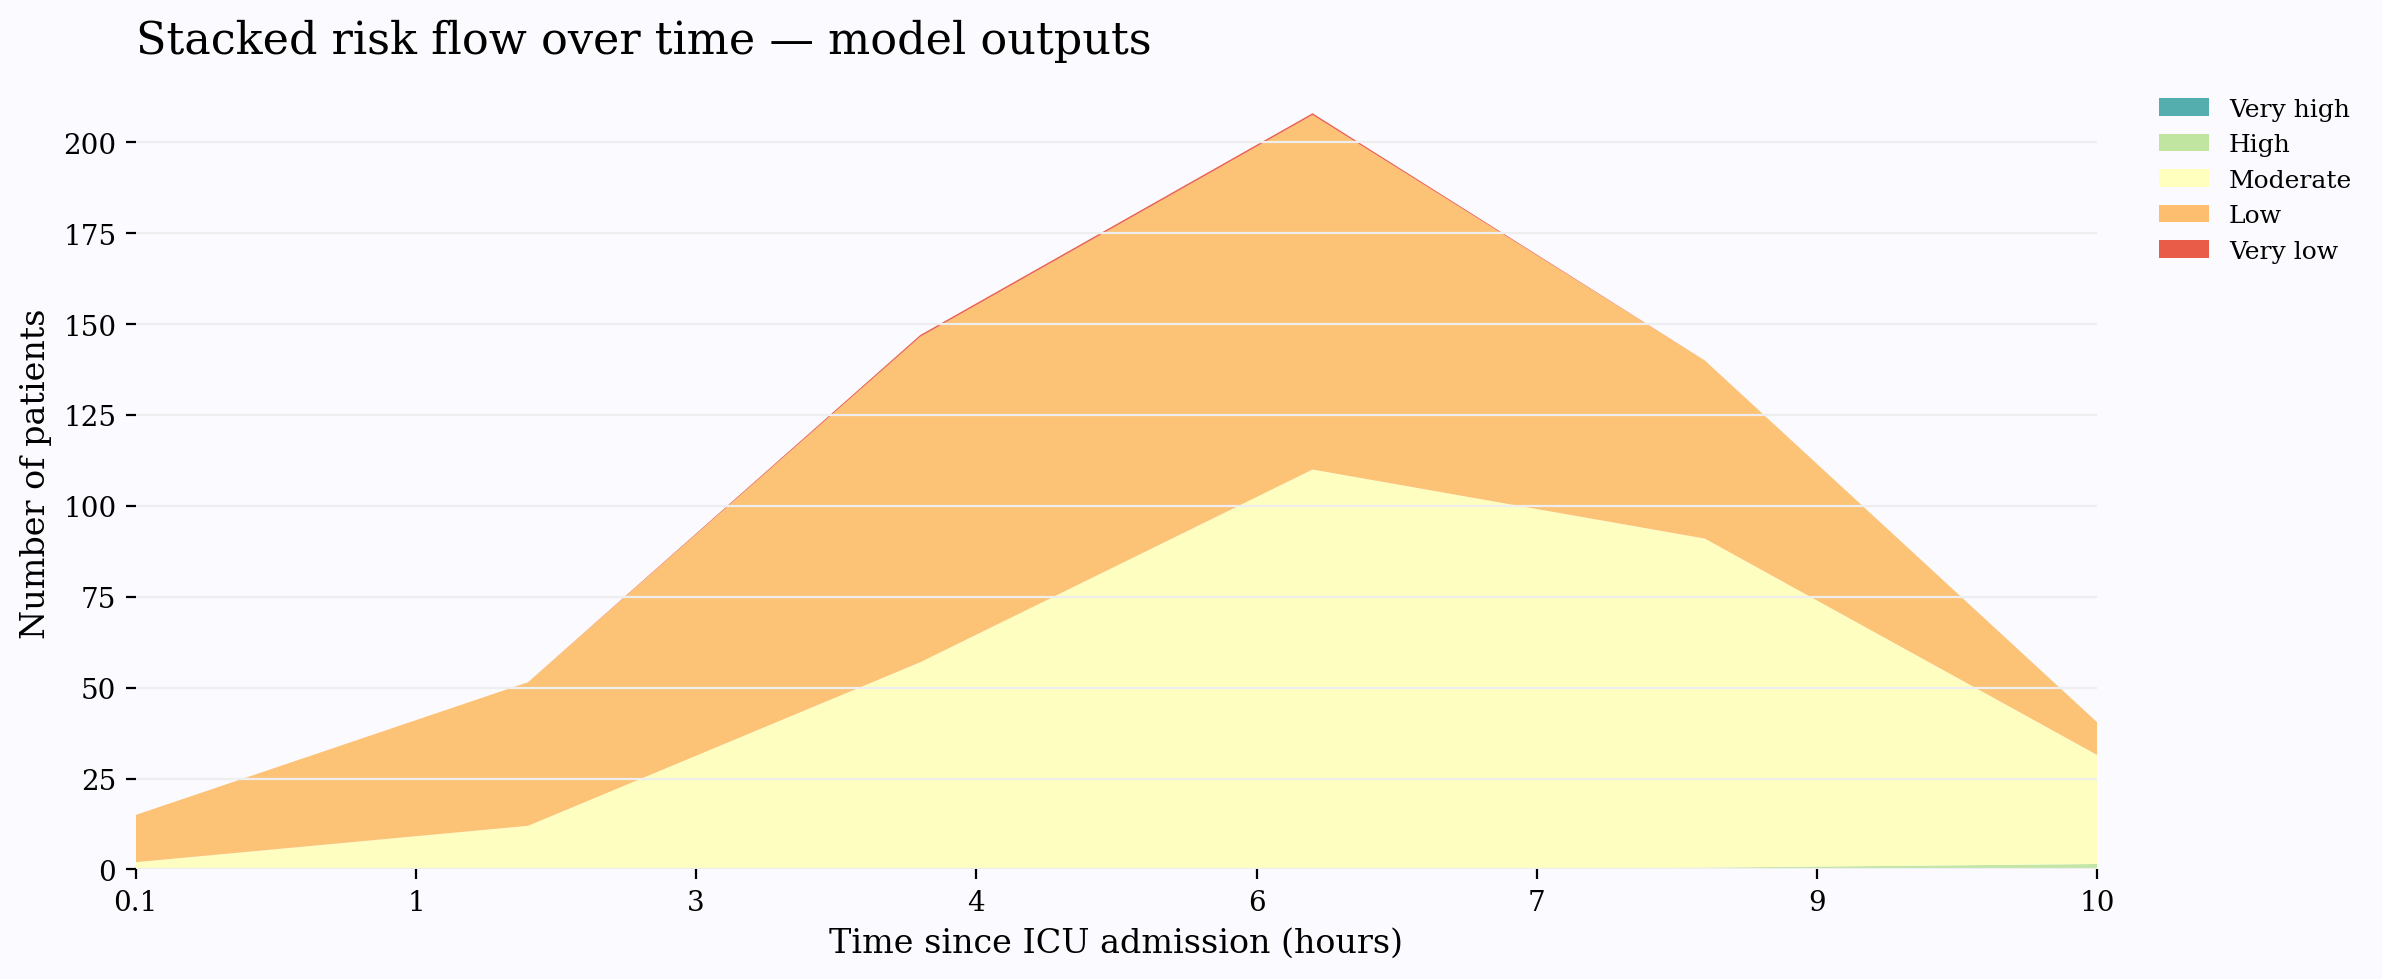

Saved: stacked_model_flow_fixed.png


In [10]:
# fixed_stacked_model_flow.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# ---------- Inputs expected from your pipeline ----------
# X_test : pd.DataFrame with a time column (e.g., 'ICULOS_last' or 'time_hours')
# y_proba: 1D array of predicted probabilities for positive class
# Optional: y_test for labels
# -------------------------------------------------------

# --- fallback synthetic demo (remove this block when you run with real data) ---
if 'X_test' not in globals():
    rng = np.random.default_rng(42)
    n = 2000
    X_test = pd.DataFrame({'ICULOS_last': np.clip(np.abs(rng.normal(48, 36, size=n)), 0.1, 240)})
    y_proba = np.clip(0.005 * X_test['ICULOS_last'] + 0.05*np.sin(X_test['ICULOS_last']/6) + rng.normal(0, 0.08, size=n), 0, 1)
    y_test = (y_proba > 0.45).astype(int)
# ------------------------------------------------------------------------------

# pick a time column
time_col = next((c for c in ['ICULOS_last', 'time_hours', 'time', 'hour'] if c in X_test.columns), None)
if time_col is None:
    # create a synthetic time sequence if none present
    X_test = X_test.copy()
    X_test['time_hours'] = np.linspace(0, 240, len(X_test))
    time_col = 'time_hours'

time_arr = np.asarray(X_test[time_col].astype(float))
y_proba = np.asarray(y_proba)

# If time range is tiny, expand a bit to avoid collapsed axis
tmin, tmax = time_arr.min(), time_arr.max()
if np.isclose(tmin, tmax):
    tmin -= 0.5
    tmax += 0.5

# sensible bin width selection
total_hours = tmax - tmin
if total_hours <= 6:
    bin_width = 0.5   # half-hour bins for very short ranges
elif total_hours <= 48:
    bin_width = 2.0   # 2-hour bins
elif total_hours <= 240:
    bin_width = 6.0   # 6-hour bins
else:
    bin_width = 24.0  # daily bins for long ranges

# build numeric bins and centers
bins = np.arange(tmin, tmax + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2.0

# categorize by probability into risk bands
risk_edges = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
risk_labels = ['Very low', 'Low', 'Moderate', 'High', 'Very high']
risk_cat = pd.cut(y_proba, bins=risk_edges, labels=risk_labels, include_lowest=True)

# Build DataFrame for aggregation
df = pd.DataFrame({ 'time': time_arr, 'y_proba': y_proba, 'risk': risk_cat })

# Assign numeric bin index using np.digitize (keeps numeric centers)
bin_idx = np.digitize(df['time'].values, bins) - 1   # -1 to match centers index
# clamp bin indices into valid range
bin_idx = np.clip(bin_idx, 0, len(bin_centers)-1)
df['bin_idx'] = bin_idx
df['bin_center'] = bin_centers[bin_idx]

# aggregate counts per bin per risk label
agg = df.groupby(['bin_center', 'risk']).size().unstack(fill_value=0).reindex(bin_centers, fill_value=0)

# If you prefer expected cases instead of counts, uncomment:
# agg = df.groupby(['bin_center', 'risk'])['y_proba'].sum().unstack(fill_value=0).reindex(bin_centers, fill_value=0)

# Light smoothing (rolling median) to make the flow look nicer
agg_smooth = agg.rolling(window=2, min_periods=1, center=True).mean()

# convert to arrays for stackplot in the right order (bottom-to-top)
# reverse order so "Very high" sits on top visually like your example
cols_order = risk_labels[::-1]
ys = [agg_smooth[c].values for c in cols_order]

# --- plotting style ---
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'serif',
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

plt.figure(figsize=(12, 5))

# choose a colourful palette, then reverse to match stacking order
palette = sns.color_palette("Spectral", n_colors=len(cols_order))[::-1]
# If you prefer custom hex colors to match the example, use:
# palette = ['#2b2a57', '#6f2a5b', '#d95d8b', '#ff7f50', '#ffd1a3'][::-1]

# stackplot expects x sorted
x = bin_centers
# ensure x is sorted (it should be)
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
ys_sorted = [y[sort_idx] for y in ys]

# stackplot
plt.stackplot(x_sorted, *ys_sorted, colors=palette, edgecolor='none', alpha=0.95)

# format axis & grid
plt.xlim(x_sorted[0], x_sorted[-1])
plt.xlabel('Time since ICU admission (hours)')
plt.ylabel('Number of patients')
plt.title('Stacked risk flow over time — model outputs', loc='left', pad=8)

plt.grid(axis='y', color='#eeeeee')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# Add legend (map back to original labels, top-to-bottom)
legend_handles = [plt.Rectangle((0,0),1,1, facecolor=c) for c in palette]
legend_labels = cols_order
plt.legend(legend_handles, legend_labels, loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)

# Annotate the peak of "Very high" band (if present)
if 'Very high' in agg_smooth.columns:
    arr = agg_smooth['Very high'].values
    if arr.sum() > 0:
        idx_max = np.argmax(arr)
        x_peak = x_sorted[idx_max]
        # compute stacked top at that bin to place annotation
        stacked_at_peak = sum(agg_smooth.iloc[idx_max][cols_order])
        # compute cumulative bottom at that label's center
        cum_vals = np.cumsum([agg_smooth.iloc[idx_max][c] for c in cols_order])
        # find midpoint of the "Very high" segment (it's the first in reversed list)
        y_mid = cum_vals[0] / 2.0
        plt.annotate("Very high\nrisk surge",
                     xy=(x_peak, y_mid),
                     xytext=(x_peak, y_mid + max(agg_smooth.sum(axis=1))*0.08),
                     ha='center', va='bottom',
                     fontsize=9, weight='bold',
                     bbox=dict(boxstyle="round,pad=0.3", fc="#de2d26", alpha=0.9),
                     arrowprops=dict(arrowstyle='->', color='#800000', lw=1.0))

# tidy ticks: show a few x ticks
num_xticks = 8
xticks = np.linspace(x_sorted[0], x_sorted[-1], num_xticks)
plt.xticks(xticks, [f"{t:.0f}" if abs(t) >= 1 else f"{t:.1f}" for t in xticks])

# save & show
outname = "stacked_model_flow_fixed.png"
plt.tight_layout()
plt.savefig(outname, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", outname)


/tmp/ipython-input-496274145.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['bin_center', 'band'])['y_proba'].sum().unstack(fill_value=0).reindex(bin_centers, fill_value=0)


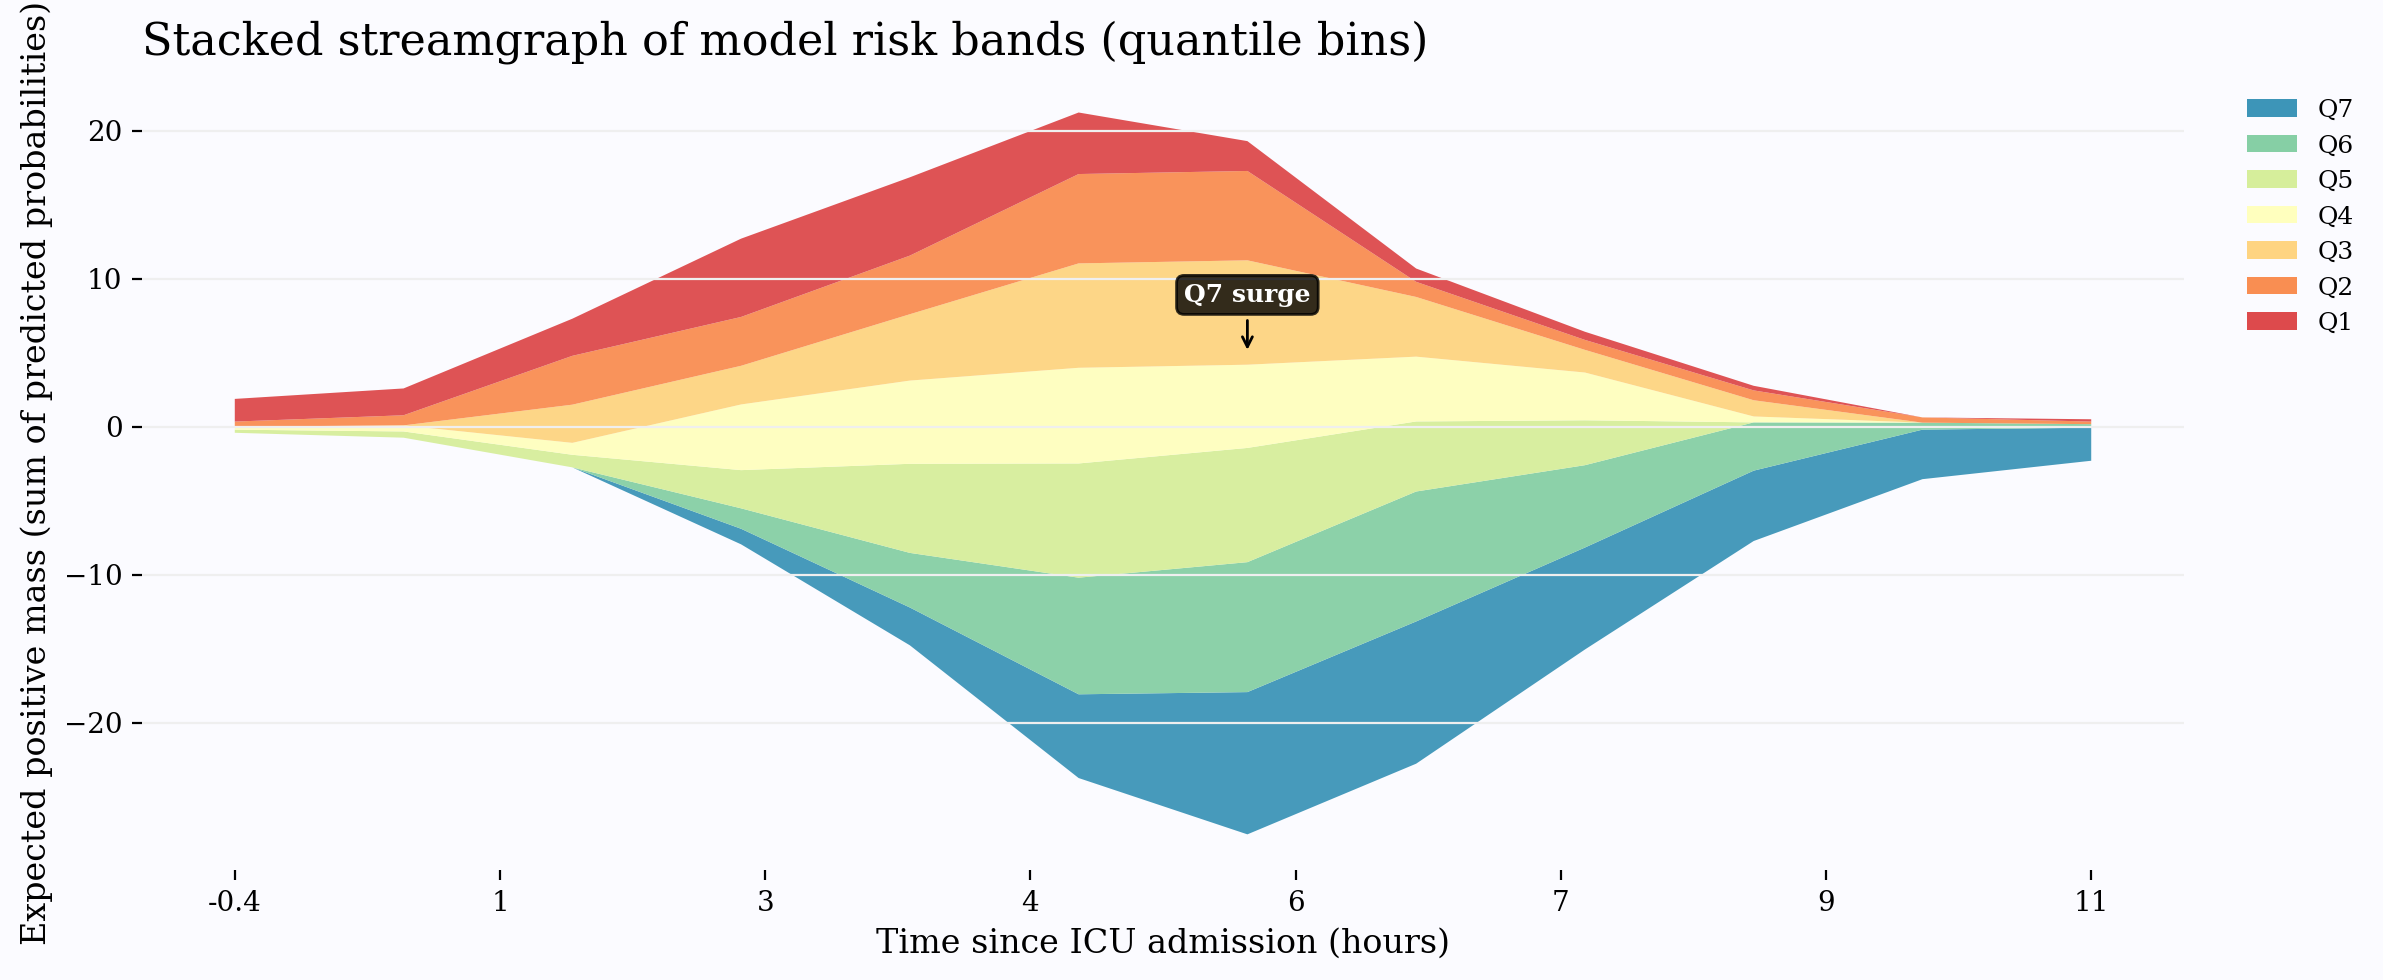

Saved: stacked_streamgraph_quantile_bins.png


In [11]:
# stacked_streamgraph_more_mountains.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ---------- Inputs from your pipeline ----------
# X_test : pd.DataFrame (must contain a time column like 'ICULOS_last' or 'time_hours')
# y_proba: np.array of predicted probabilities (positive class)
# If not present, this block creates synthetic demo data.
if 'X_test' not in globals():
    rng = np.random.default_rng(42)
    n = 2000
    X_test = pd.DataFrame({
        'ICULOS_last': np.clip(np.abs(rng.normal(48, 36, size=n)), 0.1, 240)
    })
    # synthetic predicted probabilities with varied structure so quantiles produce many mountains
    y_proba = np.clip(
        0.02*np.sin(X_test['ICULOS_last']/3.0) +
        0.004*X_test['ICULOS_last'] +
        0.2*np.exp(-0.5*((X_test['ICULOS_last']-60)/30)**2) +
        rng.normal(0, 0.09, size=n),
        0, 1
    )

# choose time column
time_col = next((c for c in ['ICULOS_last', 'time_hours', 'time', 'hour'] if c in X_test.columns), None)
if time_col is None:
    X_test = X_test.copy()
    X_test['time_hours'] = np.linspace(0, 240, len(X_test))
    time_col = 'time_hours'

time_arr = np.asarray(X_test[time_col].astype(float))
y_proba = np.asarray(y_proba)

# ---------- Parameters you can tweak ----------
q = 7                 # number of quantile bands (increase for more mountains, e.g. 8-12)
bin_width = None      # None -> automatic based on span; or set e.g. 6 (hours)
smooth_win = 3        # smoothing window (in bins), increase to smooth more
use_expected_cases = True  # if True, sum probabilities per bin; else use raw counts

# ---------- Numeric binning ----------
tmin, tmax = time_arr.min(), time_arr.max()
span = tmax - tmin
if bin_width is None:
    # choose bin width by span for reasonable resolution
    if span <= 6:
        bin_width = 0.25
    elif span <= 48:
        bin_width = 1.0
    elif span <= 240:
        bin_width = 3.0
    else:
        bin_width = 24.0

bins = np.arange(tmin, tmax + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2.0

# ---------- Create quantile-based risk bands to ensure each band has data ----------
# qcut may fail if duplicates — use rank-based cut as fallback
try:
    band_labels = [f'Q{i+1}' for i in range(q)]
    risk_cat = pd.qcut(y_proba, q=q, labels=band_labels, duplicates='drop')
    # if qcut returned fewer than q bins (rare), fall back to rank-based
    if len(np.unique(risk_cat.codes)) < q:
        raise Exception("qcut produced fewer bins than requested")
except Exception:
    # rank-based fallback
    ranks = pd.Series(y_proba).rank(method='first')  # 1..n
    bins_idx = np.ceil(ranks / (len(y_proba)/q)).astype(int).clip(1, q)
    band_labels = [f'B{i+1}' for i in range(q)]
    risk_cat = pd.Categorical([band_labels[i-1] for i in bins_idx])

# ---------- Build a DataFrame and aggregate (sum probs -> expected new cases) ----------
df = pd.DataFrame({'time': time_arr, 'y_proba': y_proba, 'band': risk_cat})
# digitize time into numeric bin indices (keeps numeric centers)
bin_idx = np.digitize(df['time'].values, bins) - 1
bin_idx = np.clip(bin_idx, 0, len(bin_centers)-1)
df['bin_center'] = bin_centers[bin_idx]

# aggregate
if use_expected_cases:
    agg = df.groupby(['bin_center', 'band'])['y_proba'].sum().unstack(fill_value=0).reindex(bin_centers, fill_value=0)
else:
    agg = df.groupby(['bin_center', 'band']).size().unstack(fill_value=0).reindex(bin_centers, fill_value=0)

# ---------- Smoothing: simple rolling average across bins (axis=0 windows) ----------
agg_smooth = agg.rolling(window=smooth_win, min_periods=1, center=True).median()

# ensure ordering of bands produces pleasing layering (choose colormap)
bands_order = list(agg_smooth.columns)  # Q1..Qq
# reverse for visually prominent top layer (optional)
bands_order = bands_order[::-1]

ys = [agg_smooth[col].values for col in bands_order]
x = bin_centers

# optional small vertical scaling to increase "mountain" visibility
scale_factor = 1.0
ys = [y * scale_factor for y in ys]

# ---------- Plot as a streamgraph / stacked area with 'wiggle' baseline ----------
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'serif',
    'axes.titlesize': 16,
    'axes.labelsize': 12,
})

plt.figure(figsize=(12,5))

# choose a colourful palette with q distinct colors
palette = sns.color_palette("Spectral", n_colors=len(bands_order))[::-1]

# Matplotlib stackplot with baseline='wiggle' gives streamgraph-like shape
# NOTE: baseline accepted by plt.stackplot in Matplotlib 3.3+
try:
    plt.stackplot(x, *ys, colors=palette, baseline='wiggle', edgecolor='none', alpha=0.95)
except TypeError:
    # older Matplotlib versions may not accept baseline param; fallback to classical stack
    plt.stackplot(x, *ys, colors=palette, edgecolor='none', alpha=0.95)

# format and polish
plt.xlabel('Time since ICU admission (hours)')
plt.ylabel('Expected positive mass (sum of predicted probabilities)' if use_expected_cases else 'Number of patients')
plt.title('Stacked streamgraph of model risk bands (quantile bins)', loc='left', pad=8)
plt.grid(axis='y', color='#efefef')

# tidy spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# legend with readable labels (map Q1.. to ordinal descriptive labels if you want)
legend_handles = [plt.Rectangle((0,0),1,1, facecolor=c) for c in palette]
legend_labels = bands_order
plt.legend(legend_handles, legend_labels, loc='upper left', bbox_to_anchor=(1.02,1.0), frameon=False)

# annotate a prominent band peak somewhere (choose band with max total)
total_per_band = agg_smooth.sum(axis=0)
max_band = total_per_band.idxmax()
if max_band in agg_smooth.columns:
    idx_peak = np.argmax(agg_smooth[max_band].values)
    x_peak = x[idx_peak]
    # compute cumulative sums at that bin for annotation placement
    cumulative = np.cumsum([agg_smooth[c].iloc[idx_peak] for c in bands_order])
    # midpoint of that band's segment:
    # find index of max_band in bands_order
    k = bands_order.index(max_band)
    bottom = cumulative[k-1] if k-1 >= 0 else 0.0
    top = cumulative[k]
    y_mid = (bottom + top) / 2.0
    plt.annotate(f"{max_band} surge",
                 xy=(x_peak, y_mid),
                 xytext=(x_peak, y_mid + cumulative[-1]*0.07),
                 ha='center', va='bottom',
                 fontsize=9, weight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.8),
                 color='white',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

# Set xticks to a reasonable number
num_xticks = 8
xticks = np.linspace(x.min(), x.max(), num_xticks)
plt.xticks(xticks, [f"{t:.0f}" if abs(t)>=1 else f"{t:.1f}" for t in xticks])

plt.tight_layout()
outname = "stacked_streamgraph_quantile_bins.png"
plt.savefig(outname, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", outname)


/tmp/ipython-input-662081220.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby(['bin_center', 'band'])['y_proba'].sum().unstack(fill_value=0).reindex(bin_centers, fill_value=0)


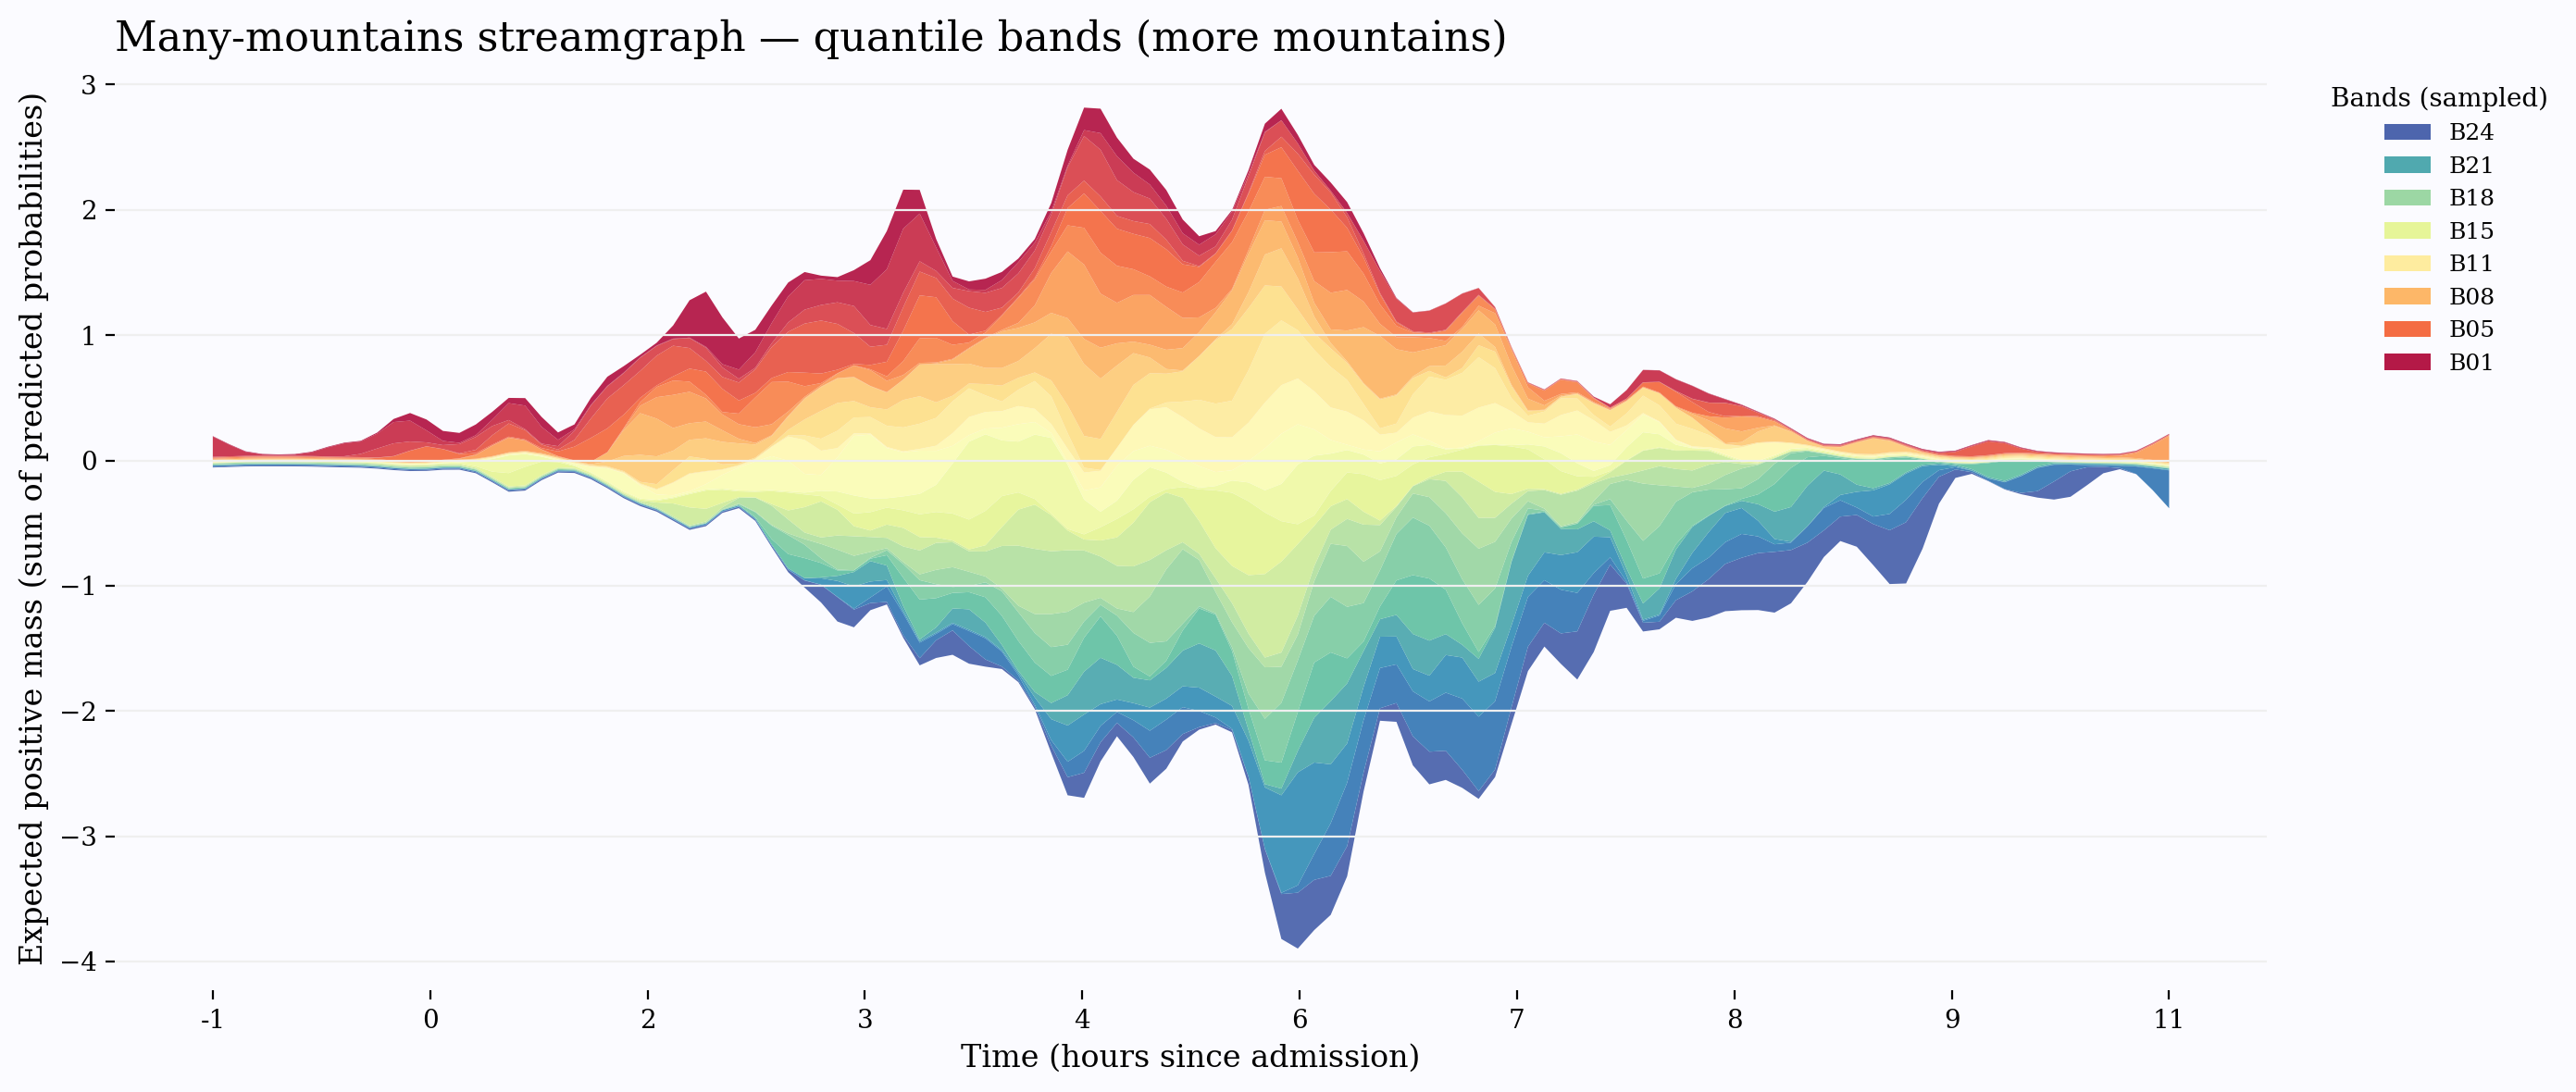

Saved: many_mountains_streamgraph.png


In [12]:
# many_mountains_streamgraph.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d

# ---------- Inputs ----------
# X_test: pd.DataFrame with time column (e.g., 'ICULOS_last' or 'time_hours')
# y_proba: 1D array of predicted probabilities
# If not present, this demo will generate synthetic data.
if 'X_test' not in globals():
    rng = np.random.default_rng(42)
    n = 5000
    X_test = pd.DataFrame({'ICULOS_last': np.clip(np.abs(rng.normal(48, 40, size=n)), 0.1, 240)})
    y_proba = np.clip(
        0.02*np.sin(X_test['ICULOS_last']/2.0) +
        0.004*X_test['ICULOS_last'] +
        0.3*np.exp(-0.5*((X_test['ICULOS_last']-60)/30)**2) +
        rng.normal(0, 0.12, size=n),
        0, 1
    )

time_col = next((c for c in ['ICULOS_last', 'time_hours', 'time', 'hour'] if c in X_test.columns), None)
if time_col is None:
    X_test = X_test.copy()
    X_test['time_hours'] = np.linspace(0, 240, len(X_test))
    time_col = 'time_hours'

time_arr = np.asarray(X_test[time_col].astype(float))
y_proba = np.asarray(y_proba)

# ---------- TUNABLE PARAMETERS (increase to get more mountains) ----------
q = 24               # number of quantile bands (try 24, 30, 40)
bin_width = (time_arr.max()-time_arr.min())/120.0  # many small bins (120 bins across span)
smooth_sigma = 1.2   # gaussian smoothing sigma (in bins) -- lower keeps more detail
modulation_strength = 0.10  # small band-wise sinusoidal modulation
use_expected_cases = True   # sum probabilities (better for mountain mass)
# -----------------------------------------------------------------------

# Numeric binning
tmin, tmax = time_arr.min(), time_arr.max()
bins = np.arange(tmin, tmax + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2.0

# Quantile-based bands (guarantees filled bands)
try:
    band_labels = [f'B{i+1:02d}' for i in range(q)]
    risk_cat = pd.qcut(y_proba, q=q, labels=band_labels, duplicates='drop')
    if len(np.unique(risk_cat)) < q:
        raise Exception("qcut produced fewer bins than requested")
except Exception:
    # rank fallback
    ranks = pd.Series(y_proba).rank(method='first')
    bins_idx = np.ceil(ranks / (len(y_proba)/q)).astype(int).clip(1, q)
    band_labels = [f'B{i+1:02d}' for i in range(q)]
    risk_cat = pd.Categorical([band_labels[i-1] for i in bins_idx])

# Build DataFrame and aggregate
df = pd.DataFrame({'time': time_arr, 'y_proba': y_proba, 'band': risk_cat})
bin_idx = np.digitize(df['time'].values, bins) - 1
bin_idx = np.clip(bin_idx, 0, len(bin_centers)-1)
df['bin_center'] = bin_centers[bin_idx]

if use_expected_cases:
    agg = df.groupby(['bin_center', 'band'])['y_proba'].sum().unstack(fill_value=0).reindex(bin_centers, fill_value=0)
else:
    agg = df.groupby(['bin_center', 'band']).size().unstack(fill_value=0).reindex(bin_centers, fill_value=0)

# Convert to numpy array in band order
bands_order = list(agg.columns)
Y = np.vstack([agg[band].values for band in bands_order])  # shape (q, n_bins)

# Add tiny band-wise modulation to create ripples/mountains
n_bins = Y.shape[1]
rng = np.random.default_rng(123)
for i in range(Y.shape[0]):
    freq = 0.5 + rng.random() * 3.0            # band-specific frequency
    phase = rng.random() * 2 * np.pi
    modulation = (np.sin(np.linspace(0, freq * 2*np.pi, n_bins) + phase))
    modulation = modulation - modulation.min()
    modulation = modulation / (modulation.max() + 1e-9)
    Y[i] = Y[i] + modulation_strength * np.mean(Y[i]) * modulation

# Smooth each band's time-series with gaussian filter
for i in range(Y.shape[0]):
    Y[i] = gaussian_filter1d(Y[i], sigma=smooth_sigma, mode='reflect')

# small vertical scaling for visibility
Y = Y * 1.0

# Reverse order so highest-index band appears on top (aesthetic)
bands_order_rev = bands_order[::-1]
Y_rev = Y[::-1, :]

# ---------- Plotting ----------
mpl.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'serif',
    'axes.titlesize': 16,
    'axes.labelsize': 12
})

plt.figure(figsize=(14, 6))
palette = sns.color_palette("Spectral", n_colors=Y_rev.shape[0])[::-1]

# use stackplot with wiggle baseline for streamgraph feel
try:
    plt.stackplot(bin_centers, *Y_rev, colors=palette, baseline='wiggle', alpha=0.95)
except TypeError:
    plt.stackplot(bin_centers, *Y_rev, colors=palette, alpha=0.95)

plt.title('Many-mountains streamgraph — quantile bands (more mountains)', loc='left')
plt.xlabel('Time (hours since admission)')
plt.ylabel('Expected positive mass (sum of predicted probabilities)')
plt.grid(axis='y', color='#efefef')
ax = plt.gca(); [s.set_visible(False) for s in ax.spines.values()]

# Legend (sample a subset to avoid crowding)
num_legend = min(8, len(bands_order_rev))
legend_indices = np.linspace(0, len(bands_order_rev)-1, num_legend).astype(int)
handles = [plt.Rectangle((0,0),1,1, facecolor=palette[i]) for i in legend_indices]
labels = [bands_order_rev[i] for i in legend_indices]
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02,1.0), frameon=False, title='Bands (sampled)')

# Tidy xticks
num_xticks = 10
xticks = np.linspace(bin_centers.min(), bin_centers.max(), num_xticks)
plt.xticks(xticks, [f"{t:.0f}" for t in xticks])

plt.tight_layout()
outname = "many_mountains_streamgraph.png"
plt.savefig(outname, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", outname)


/tmp/ipython-input-2644873655.py:106: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


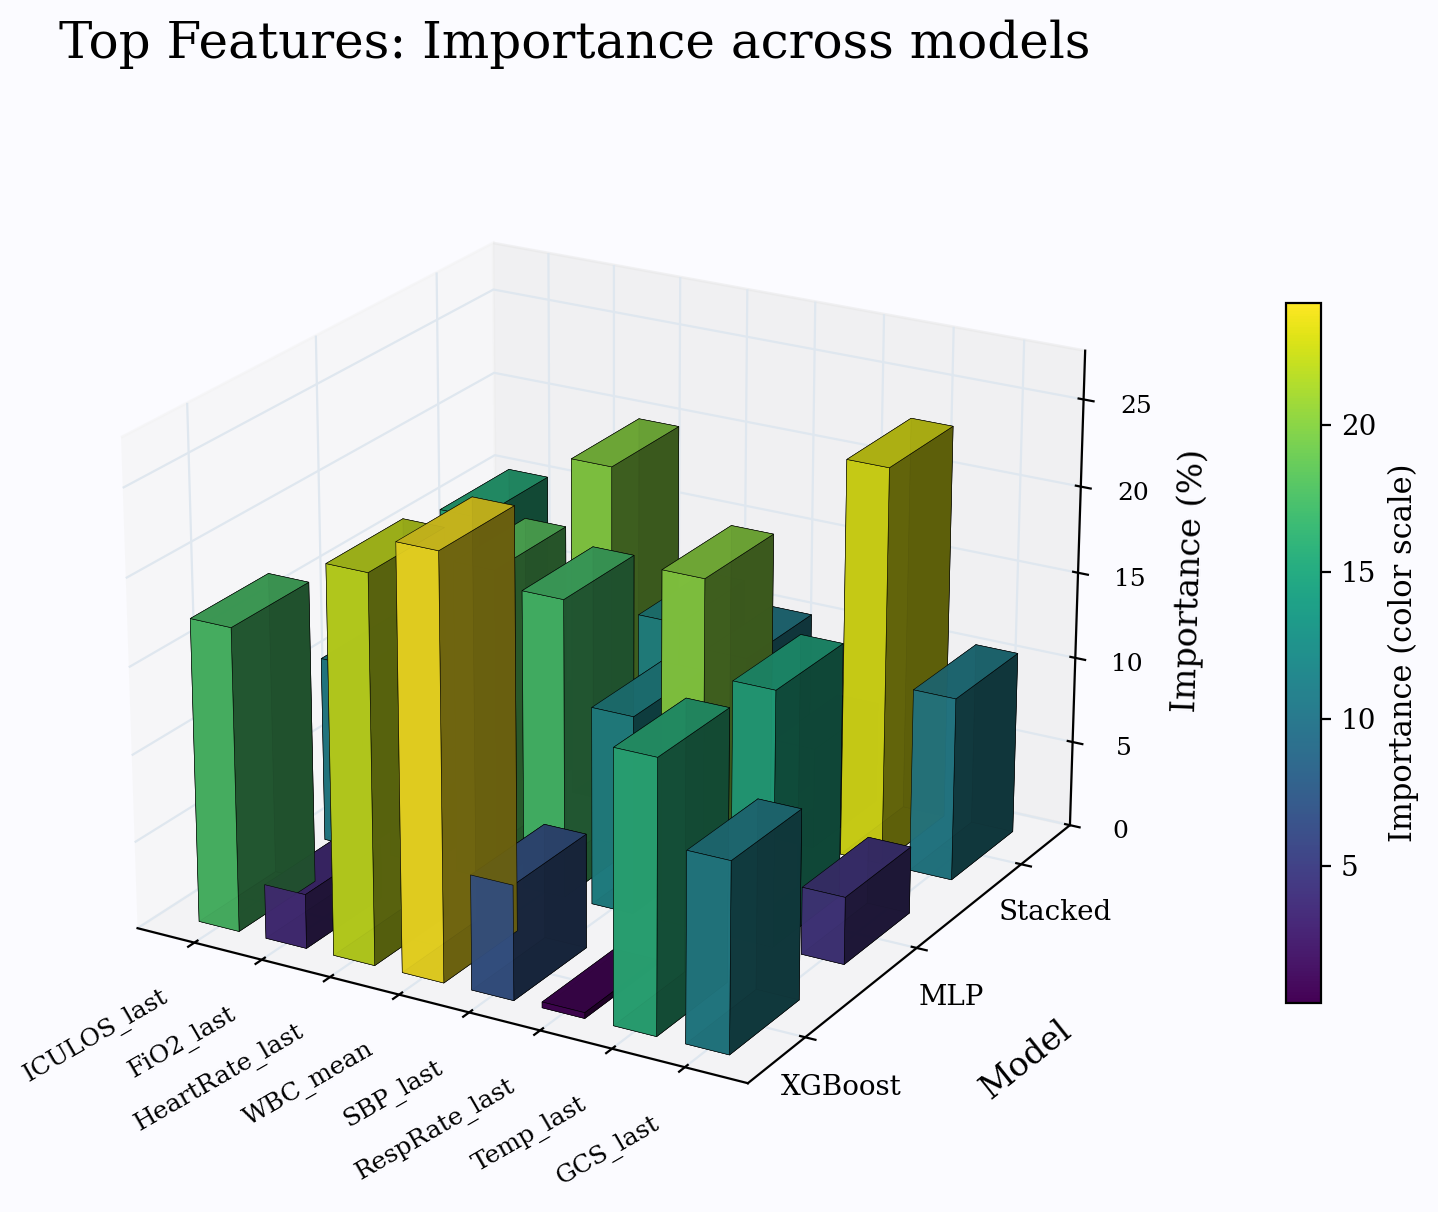

Saved: 3d_feature_importance_clean_final.png


In [16]:
# final_3d_feature_importance_clean.py
# Ready-to-run script: 3D bar chart of feature importances across models
# - X axis: feature names (labels moved down)
# - Y axis: model names
# - Z axis: importance (%)
# - No numeric labels above bars
# - Proper colorbar attached to the 3D axes
#
# Replace the synthetic importance_matrix with your real values if available.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 required for 3D
import seaborn as sns

# ---------------------------
# Example data (replace with your real importance matrix)
# ---------------------------
features = [
    "ICULOS_last", "FiO2_last", "HeartRate_last", "WBC_mean",
    "SBP_last", "RespRate_last", "Temp_last", "GCS_last"
]
models = ["XGBoost", "MLP", "Stacked"]

# Synthetic importance matrix (models x features). Replace this with your actual numbers.
rng = np.random.default_rng(42)
importance_matrix = np.abs(rng.normal(loc=0.2, scale=0.15, size=(len(models), len(features))))
# normalize each model's row to percent (optional but makes the z-scale readable)
importance_matrix = importance_matrix / (importance_matrix.sum(axis=1, keepdims=True) + 1e-12) * 100.0

# ---------------------------
# Plot settings
# ---------------------------
mpl.rcParams.update({
    "figure.dpi": 200,
    "font.family": "serif",
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10
})

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

# coordinates for bars
_x = np.arange(len(features))
_y = np.arange(len(models))
_xx, _yy = np.meshgrid(_x, _y)
x = _xx.ravel()
y = _yy.ravel()
z = np.zeros_like(x)

# heights for bars
dz = importance_matrix.ravel()

# bar sizes (widths)
dx = 0.6
dy = 0.6

# color mapping for bars (based on height)
max_dz = dz.max() if dz.size and dz.max() > 0 else 1.0
cmap = plt.get_cmap("viridis")
colors = cmap(dz / (max_dz + 1e-12))

# draw bars
ax.bar3d(x, y, z, dx, dy, dz, color=colors, shade=True,
         edgecolor='k', linewidth=0.2, alpha=0.95)

# ---------------------------
# Axes labels and ticks
# ---------------------------
# Move the X-axis label further down (~0.5 cm) using labelpad
ax.set_xlabel("Features", labelpad=50)   # increased labelpad to move label lower (~0.5 cm)
# Set xticks and rotate them for readability
ax.set_xticks(_x + dx / 2.0)
ax.set_xticklabels(features, rotation=30, ha='right', fontsize=9)

# Y axis (models)
ax.set_ylabel("Model", labelpad=15)
ax.set_yticks(_y + dy / 2.0)
ax.set_yticklabels(models, fontsize=10)

# Z axis and title
ax.set_zlabel("Importance (%)", fontsize=12)
ax.set_title("Top Features: Importance across models", pad=20, loc='left')

# ---------------------------
# Colorbar: attach to the same axes
# ---------------------------
mappable = mpl.cm.ScalarMappable(cmap=cmap)
mappable.set_array(dz)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.65, pad=0.08)
cbar.set_label("Importance (color scale)", fontsize=11)

# ---------------------------
# Do NOT add numeric labels above bars (removed)
# ---------------------------

# Viewing angle and limits
ax.view_init(elev=22, azim=-60)
ax.set_zlim(0, max(10, dz.max() * 1.15))

# Tidy up and save
plt.tight_layout()
outfile = "3d_feature_importance_clean_final.png"
plt.savefig(outfile, dpi=600, bbox_inches='tight')
plt.show()

print("Saved:", outfile)
